In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==========================================================
# Automated EPM + Fiber Photometry pipeline
# Flexible to zone numbering & header differences
# ==========================================================

# ----------------------------------------------------------
# Main configuration
# ----------------------------------------------------------


main_dir = Path(".").resolve()
timepoints = ["W3"]



nosepoint_substrings = [
    "In Zone",   # the only relevant EthoVision column
]

zone_colors = {
    "In Zone": "#FF7F00",   # orange, stands for open zone
}


video_fps = 50.0
fp_fps = 50.0

figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(parents=True, exist_ok=True)

video_fps = 50.0
fp_fps = 50.0

figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Helper functions
# ==========================================================

def _mouse_genotype_tag(mouse_id: str):
    id_clean = mouse_id.strip()
    if id_clean in {"372", "376", "423", "398", "400", "459"}:
        return "NE"
    if id_clean in {"374", "429", "461", "463", "402"}:
        return "WT"
    return None


def _read_export_and_get_fp_and_mouse_id(xl_path: Path):
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()

    # FP file
    match_fp = df[key_col == "fp file"]
    if match_fp.empty:
        raise ValueError(f"'FP file' not found in {xl_path.name}")
    fp_id = str(df.iloc[match_fp.index[0], 1]).strip()

    # Mouse ID
    match_id = df[key_col == "id"]
    if match_id.empty:
        raise ValueError(f"'ID' row not found in {xl_path.name}")
    mouse_id = str(df.iloc[match_id.index[0], 1]).strip()

    return fp_id, mouse_id


def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str):
    """Use folder to detect FP vs timestamp CSV; FP is any CSV that is not timestamp."""
    fp_csv = None
    ts_csv = None
    for p in fp_folder.glob("*.csv"):
        name = p.name.lower()
        if "time" in name or "timestamp" in name:
            ts_csv = p
        else:
            fp_csv = p

    if fp_csv is None:
        raise FileNotFoundError(f"No FP CSV found in {fp_folder}")
    if ts_csv is None:
        raise FileNotFoundError(f"No timestamp CSV found in {fp_folder}")

    return fp_csv, ts_csv


def _coerce_bool_col(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])


def _get_video_window(ts: pd.DataFrame):
    tcol = next(c for c in ts.columns if "time" in c.lower())
    t = pd.to_numeric(ts[tcol], errors="coerce")

    scol = None
    for c in ts.columns:
        if "digital" in c.lower() or "state" in c.lower():
            scol = c
            break

    if scol is None:
        return float(t.iloc[0]), float(t.iloc[-1])

    state = _coerce_bool_col(ts[scol])

    if state.sum() == 0 or (~state).sum() == 0:
        return float(t.iloc[0]), float(t.iloc[-1])

    try:
        video_start = float(t[state].iloc[0])
        video_stop = float(t[~state].iloc[0])
        if video_stop > video_start:
            return video_start, video_stop
    except:
        pass

    return float(t.iloc[0]), float(t.iloc[-1])


def _build_time_vector_from_fp(fp_df):
    if "SystemTimestamp" in fp_df.columns:
        ts = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce")
        if ts.notna().sum() > len(ts) * 0.8:
            return ts.to_numpy()
    return np.arange(len(fp_df)) / fp_fps


def _snap_down_index(t, target):
    return max(0, np.searchsorted(t, target, side="right") - 1)


def _trim_fp_to_window(fp_df, start, stop):
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n]

    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    out = fp_df.iloc[i0:i1+1].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out


def _detect_header_row(eth_path: Path):
    preview = pd.read_excel(eth_path, header=None, nrows=50)
    firstcell = str(preview.iloc[0, 0])
    if "number of header lines" in firstcell.lower():
        m = re.findall(r"\d+", firstcell)
        if m:
            return int(m[0])

    col0 = preview.iloc[:, 0].astype(str)
    hits = col0[col0.str.contains("Trial time", case=False, na=False)]
    if not hits.empty:
        return hits.index[0]

    raise ValueError(f"Cannot detect header row in {eth_path.name}")


def _load_ethovision_sheet_with_targets(eth_path: Path, video_fps: float):
    header_row = _detect_header_row(eth_path)
    eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")

    tcol = next((c for c in eth.columns if "time" in c.lower()), None)
    if tcol:
        eth["Time_s"] = pd.to_numeric(eth[tcol], errors="coerce")
    else:
        eth["Time_s"] = np.arange(len(eth)) / video_fps

    matched_cols = []
    for sub in nosepoint_substrings:
        for col in eth.columns:
            if sub in str(col):
                matched_cols.append(col)
                break

    if not matched_cols:
        raise ValueError(f"No nose-point zones found in {eth_path.name}")

    return eth[["Time_s"] + matched_cols].copy(), matched_cols


# === FIXED VERSION OF _ethogram_segments ===
def _ethogram_segments(eth, beh_cols):
    segments = []
    for beh in beh_cols:
        col = eth[beh]
        # FIX: if duplicate columns returned as DataFrame, take the first column
        if isinstance(col, pd.DataFrame):
            col = col.iloc[:, 0]

        mask = col == 1

        if mask.sum() == 0:
            continue

        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff == 1, "Time_s"]
        ends = eth.loc[diff == -1, "Time_s"]

        if mask.iloc[0]:
            starts = pd.concat([pd.Series([eth["Time_s"].iloc[0]]), starts])
        if mask.iloc[-1]:
            ends = pd.concat([ends, pd.Series([eth["Time_s"].iloc[-1]])])

        for s, e in zip(starts, ends):
            segments.append({
                "Behavior": beh,
                "Start_time_s": float(s),
                "End_time_s": float(e),
                "Duration_s": float(e - s)
            })

    return pd.DataFrame(segments)


def _guess_zone_color(colname):
    for sub, color in zone_colors.items():
        if sub in colname:
            return color
    return "black"


def _plot_trial(fp_trim, eth_timeline, beh_cols, out_png, title_prefix):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1]})

    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns
        if pd.api.types.is_numeric_dtype(fp_trim[c])
        and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
    )

    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)")
    axes[0].grid(True)

    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)")
    axes[1].grid(True)

    for i, beh in enumerate(beh_cols):
        color = _guess_zone_color(beh)
        subset = eth_timeline[eth_timeline["Behavior"] == beh]
        for _, row in subset.iterrows():
            axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

    axes[2].set_yticks(range(len(beh_cols)))
    axes[2].set_yticklabels(beh_cols)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Time in zone (nose-point)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)


def _extract_led_traces(fp_trim, chan):
    iso = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].rename(columns={chan: f"{chan}_iso415"})
    gcamp = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].rename(columns={chan: f"{chan}_gcamp470"})
    return iso.reset_index(drop=True), gcamp.reset_index(drop=True)


# ==========================================================
# Main loop
# ==========================================================

fp_traces = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")
    tp_dir = main_dir / tp
    export_dir = tp_dir / "Export files"

    fig_dir_tp = figures_main_dir / tp
    fig_dir_raw = fig_dir_tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)

    trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
    if not trial_files:
        print(f"[WARN] No Raw data-*.xlsx files in {export_dir}")
        continue

    for eth_path in trial_files:
        try:
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
            geno = _mouse_genotype_tag(mouse_id)

            fp_folder = tp_dir / fp_id
            fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

            fp = pd.read_csv(fp_csv, encoding="utf-8")
            fp = fp[fp["LedState"].isin([1, 2])]

            ts = pd.read_csv(ts_csv, encoding="utf-8")
            video_start, video_stop = _get_video_window(ts)
            fp_trim = _trim_fp_to_window(fp, video_start, video_stop)

            chan = "G0" if "G0" in fp_trim.columns else next(
                c for c in fp_trim.columns
                if pd.api.types.is_numeric_dtype(fp_trim[c])
                and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
            )

            iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

            trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
            mouse_label = f"ID{mouse_id}" + (f"_{geno}" if geno else "")
            file_stub = f"{mouse_label}__{fp_id}__{trial_stub}"

            eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, video_fps)
            timeline = _ethogram_segments(eth, matched_cols)

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
                "timeline": timeline,
                "beh_cols": matched_cols
            }

            out_png = fig_dir_raw / f"{file_stub}_zones.png"
            _plot_trial(fp_trim, timeline, matched_cols, out_png,
                        title_prefix=f"{mouse_label} | {fp_id} | {trial_stub}")

            print(f"✔ {eth_path.name} → {out_png.name}")

        except Exception as e:
            print(f"[WARN] [{tp}] {eth_path.name}: {e}")


=== Processing timepoint: W3 ===
[WARN] [W3] Raw data-LDCT_W3_C1-Trial     5.xlsx: No nose-point zones found in Raw data-LDCT_W3_C1-Trial     5.xlsx
[WARN] [W3] Raw data-LDCT_W3_C1-Trial     6.xlsx: No nose-point zones found in Raw data-LDCT_W3_C1-Trial     6.xlsx
[WARN] [W3] Raw data-LDCT_W3_C1-Trial     7.xlsx: No nose-point zones found in Raw data-LDCT_W3_C1-Trial     7.xlsx
[WARN] [W3] Raw data-LDCT_W3_C1-Trial     8.xlsx: No nose-point zones found in Raw data-LDCT_W3_C1-Trial     8.xlsx
[WARN] [W3] Raw data-LDCT_W3_C1-Trial     9.xlsx: No nose-point zones found in Raw data-LDCT_W3_C1-Trial     9.xlsx
[WARN] [W3] Raw data-LDCT_W3_C2_retrack-Trial     4.xlsx: No nose-point zones found in Raw data-LDCT_W3_C2_retrack-Trial     4.xlsx
[WARN] [W3] Raw data-LDCT_W3_C2_retrack-Trial     5.xlsx: No nose-point zones found in Raw data-LDCT_W3_C2_retrack-Trial     5.xlsx
[WARN] [W3] Raw data-LDCT_W3_C2_retrack-Trial     6.xlsx: No nose-point zones found in Raw data-LDCT_W3_C2_retrack-Trial  

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==========================================================
# Automated EPM + Fiber Photometry pipeline
# Flexible to zone numbering & header differences
# ==========================================================

# ----------------------------------------------------------
# Main configuration
# ----------------------------------------------------------

main_dir = Path(".").resolve()
timepoints = ["W2", "W3"]



# # Nose-point zone substrings (FLEXIBLE MATCHING)
# nosepoint_substrings = [
#     "Arena",         # NEW
#     "O1_prevC1 / Nose-point",
#     "O2_prevC2 / Nose-point",
#     "C1_prevO1 / Nose-point",
#     "C2_prevO2 / Nose-point",
#     "NeutralZone / Nose-point",
# ]
nosepoint_substrings = [
    "In Zone",   # the only relevant EthoVision column
]


# Fixed colors keyed by inner substring (order doesn’t matter)
# zone_colors = {
#     "Arena / Nose-point": "#999999",         # grey
#     "O1_prevC1 / Nose-point": "#E41A1C",     # red
#     "O2_prevC2 / Nose-point": "#377EB8",     # blue
#     "C1_prevO1 / Nose-point": "#4DAF4A",     # green
#     "C2_prevO2 / Nose-point": "#984EA3",     # purple
#     "NeutralZone / Nose-point": "#FF7F00",   # orange
# }
zone_colors = {
    "In Zone": "#FF7F00",   # orange, stands for open zone
}


video_fps = 50.0
fp_fps = 50.0

figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Helper functions
# ==========================================================

def _mouse_genotype_tag(mouse_id: str):
    id_clean = mouse_id.strip()
    if id_clean in {"372", "376", "423", "398", "400", "459"}:
        return "NE"
    if id_clean in {"374", "429", "461", "463", "402"}:
        return "WT"
    return None


def _read_export_and_get_fp_and_mouse_id(xl_path: Path):
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()

    # FP file
    match_fp = df[key_col == "fp file"]
    if match_fp.empty:
        raise ValueError(f"'FP file' not found in {xl_path.name}")
    fp_id = str(df.iloc[match_fp.index[0], 1]).strip()

    # Mouse ID
    match_id = df[key_col == "id"]
    if match_id.empty:
        raise ValueError(f"'ID' row not found in {xl_path.name}")
    mouse_id = str(df.iloc[match_id.index[0], 1]).strip()

    # Mouse ID from "EM and cage" (value is in the column to the right)
    # match_em_cage = df[key_col == "EM and cage"]
    # if match_em_cage.empty:
    #     raise ValueError(f"'EM and cage' row not found in {xl_path.name}")

    # row_idx = match_em_cage.index[0]
    # col_idx = df.columns.get_loc(key_col)

    # mouse_id = str(df.iloc[row_idx, col_idx + 1]).strip()


    

    return fp_id, mouse_id


def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str):
    fp_csv = None
    for p in fp_folder.glob("*.csv"):
        if fp_id.lower() in p.name.lower():
            #fp_csv = p
            fil = fp_id + '.csv'
            fp_csv = fp_folder / fil
            break
    if fp_csv is None:
        raise FileNotFoundError(f"No FP CSV found in {fp_folder}")

    ts_csv = None
    for p in fp_folder.glob("*.csv"):
        if "time" in p.name.lower() or "timestamp" in p.name.lower():
            #ts_csv = p
            import os
            directory, filename = os.path.split(p)

            # Remove leading "._" if present
            new_filename = filename.lstrip("._") if filename.startswith("._") else filename

            # Join back together
            new_path = os.path.join(directory, new_filename)
            
            ts_csv = new_path
            break
    if ts_csv is None:
        raise FileNotFoundError(f"No timestamp CSV found in {fp_folder}")

    return fp_csv, ts_csv


def _coerce_bool_col(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])


def _get_video_window(ts: pd.DataFrame):
    """Robust detection of video ON/OFF timestamps."""
    # Time column
    tcol = next(c for c in ts.columns if "time" in c.lower())
    t = pd.to_numeric(ts[tcol], errors="coerce")

    # Digital channel
    scol = None
    for c in ts.columns:
        if "digital" in c.lower() or "state" in c.lower():
            scol = c
            break

    # No digital info → use full recording
    if scol is None:
        return float(t.iloc[0]), float(t.iloc[-1])

    state = _coerce_bool_col(ts[scol])

    # If no transitions → full interval
    if state.sum() == 0 or (~state).sum() == 0:
        return float(t.iloc[0]), float(t.iloc[-1])

    # Use first True and first False
    try:
        video_start = float(t[state].iloc[0])
        video_stop = float(t[~state].iloc[0])
        if video_stop > video_start:
            return video_start, video_stop
    except:
        pass

    # Fallback
    return float(t.iloc[0]), float(t.iloc[-1])


def _build_time_vector_from_fp(fp_df):
    if "SystemTimestamp" in fp_df.columns:
        ts = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce")
        if ts.notna().sum() > len(ts) * 0.8:
            return ts.to_numpy()
    return np.arange(len(fp_df)) / fp_fps


def _snap_down_index(t, target):
    return max(0, np.searchsorted(t, target, side="right") - 1)


def _trim_fp_to_window(fp_df, start, stop):
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n]

    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    out = fp_df.iloc[i0:i1+1].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out


def _detect_header_row(eth_path: Path):
    preview = pd.read_excel(eth_path, header=None, nrows=50)

    firstcell = str(preview.iloc[0, 0])
    if "number of header lines" in firstcell.lower():
        m = re.findall(r"\d+", firstcell)
        if m:
            return int(m[0])

    col0 = preview.iloc[:, 0].astype(str)
    hits = col0[col0.str.contains("Trial time", case=False, na=False)]
    if not hits.empty:
        return hits.index[0]

    raise ValueError(f"Cannot detect header row in {eth_path.name}")


# def _load_ethovision_sheet_with_targets(eth_path: Path, video_fps: float):
#     header_row = _detect_header_row(eth_path)
#     eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")

#     # Time_s
#     tcol = next((c for c in eth.columns if "time" in c.lower()), None)
#     if tcol:
#         eth["Time_s"] = pd.to_numeric(eth[tcol], errors="coerce")
#     else:
#         eth["Time_s"] = np.arange(len(eth)) / video_fps

#     # Flexible matching of nose-point zone columns
#     matched_cols = []
#     for sub in nosepoint_substrings:
#         for col in eth.columns:
#             if sub in str(col):
#                 matched_cols.append(col)
#                 break

#     if not matched_cols:
#         raise ValueError(f"No nose-point zones found in {eth_path.name}")

#     return eth[["Time_s"] + matched_cols].copy(), matched_cols

def _load_ethovision_sheet_with_targets(eth_path: Path, video_fps: float):
    header_row = _detect_header_row(eth_path)
    eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")

    # Time_s
    tcol = next((c for c in eth.columns if "time" in c.lower()), None)
    if tcol:
        eth["Time_s"] = pd.to_numeric(eth[tcol], errors="coerce")
    else:
        eth["Time_s"] = np.arange(len(eth)) / video_fps

    # Find the single "In Zone" column
    zone_col = next((c for c in eth.columns if "in zone" in c.lower()), None)
    if zone_col is None:
        raise ValueError(f"No 'In Zone' column found in {eth_path.name}")

    # Convert to binary open-zone indicator
    eth["In Zone"] = (pd.to_numeric(eth[zone_col], errors="coerce") == 1).astype(int)

    return eth[["Time_s", "In Zone"]].copy(), ["In Zone"]



# def _ethogram_segments(eth, beh_cols):
#     segments = []
#     for beh in beh_cols:
#         mask = eth[beh] == 1
#         if mask.sum() == 0:
#             continue
#         diff = mask.astype(int).diff().fillna(0)
#         starts = eth.loc[diff == 1, "Time_s"]
#         ends = eth.loc[diff == -1, "Time_s"]

#         if mask.iloc[0]:
#             starts = pd.concat([pd.Series([eth["Time_s"].iloc[0]]), starts])
#         if mask.iloc[-1]:
#             ends = pd.concat([ends, pd.Series([eth["Time_s"].iloc[-1]])])

#         for s, e in zip(starts, ends):
#             segments.append(
#                 {"Behavior": beh, "Start_time_s": float(s), "End_time_s": float(e),
#                  "Duration_s": float(e - s)}
#             )
#     return pd.DataFrame(segments)

def _ethogram_segments(eth, beh_cols):
    """Extract open-zone segments from the single 'In Zone' column."""
    col = beh_cols[0]  # "In Zone"
    mask = eth[col] == 1

    if mask.sum() == 0:
        return pd.DataFrame(columns=["Behavior", "Start_time_s", "End_time_s", "Duration_s"])

    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"]
    ends = eth.loc[diff == -1, "Time_s"]

    if mask.iloc[0]:
        starts = pd.concat([pd.Series([eth["Time_s"].iloc[0]]), starts])
    if mask.iloc[-1]:
        ends = pd.concat([ends, pd.Series([eth["Time_s"].iloc[-1]])])

    segs = []
    for s, e in zip(starts, ends):
        segs.append({
            "Behavior": col,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s),
        })

    return pd.DataFrame(segs)


def _guess_zone_color(colname):
    for sub, color in zone_colors.items():
        if sub in colname:
            return color
    return "black"


def _plot_trial(fp_trim, eth_timeline, beh_cols, out_png, title_prefix):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1]})

    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns
        if pd.api.types.is_numeric_dtype(fp_trim[c])
        and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
    )

    # LED 1 – isosbestic
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)")
    axes[0].grid(True)

    # LED 2 – GCaMP
    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)")
    axes[1].grid(True)

    # # Ethogram
    # for i, beh in enumerate(beh_cols):
    #     color = _guess_zone_color(beh)
    #     subset = eth_timeline[eth_timeline["Behavior"] == beh]
    #     for _, row in subset.iterrows():
    #         axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"],
    #                      height=0.6, color=color)

    # Single open-zone bar (In Zone = 1)
    beh = beh_cols[0]  # "In Zone"
    color = _guess_zone_color(beh)
    subset = eth_timeline[eth_timeline["Behavior"] == beh]

    for _, row in subset.iterrows():
        axes[2].barh(0, row["Duration_s"],
                    left=row["Start_time_s"],
                    height=0.6,
                    color=color)

    axes[2].set_yticks([0])
    axes[2].set_yticklabels(["Open zone"])


    axes[2].set_yticks(range(len(beh_cols)))
    axes[2].set_yticklabels(beh_cols)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Time in zone (nose-point)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)


def _extract_led_traces(fp_trim, chan):
    iso = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_iso415"})
    gcamp = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_gcamp470"})
    return iso.reset_index(drop=True), gcamp.reset_index(drop=True)


# ==========================================================
# Main loop
# ==========================================================

fp_traces = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")
    tp_dir = main_dir / tp
    export_dir = tp_dir / "Export files"

    fig_dir_tp = figures_main_dir / tp
    fig_dir_raw = fig_dir_tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)

    trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
    if not trial_files:
        print(f"[WARN] No Raw data-*.xlsx files in {export_dir}")
        continue

    for eth_path in trial_files:
        try:
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
            geno = _mouse_genotype_tag(mouse_id)

            fp_folder = tp_dir / fp_id
            fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

            # Load FP
            fp = pd.read_csv(fp_csv, encoding="utf-8")
            fp = fp[fp["LedState"].isin([1, 2])]

            # Align timestamps
            ts = pd.read_csv(ts_csv, encoding="utf-8")
            video_start, video_stop = _get_video_window(ts)
            fp_trim = _trim_fp_to_window(fp, video_start, video_stop)

            # Detect channel
            chan = "G0" if "G0" in fp_trim.columns else next(
                c for c in fp_trim.columns
                if pd.api.types.is_numeric_dtype(fp_trim[c])
                and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
            )

            iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

            trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
            mouse_label = f"ID{mouse_id}" + (f"_{geno}" if geno else "")
            file_stub = f"{mouse_label}__{fp_id}__{trial_stub}"

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
            }

            # Load EthoVision
            eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, video_fps)
            timeline = _ethogram_segments(eth, matched_cols) #timeline for behaviours

            # added this to store timeline to use in kernel smoothing in later code blocks
            # --- inside your main loop, after timeline is created ---
            #timeline = _ethogram_segments(eth, matched_cols)  # already there

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
                "timeline": timeline,   # <-- NEW: store timeline
                "beh_cols": matched_cols
            }


            # Plot trial
            out_png = fig_dir_raw / f"{file_stub}_zones.png"
            _plot_trial(fp_trim, timeline, matched_cols, out_png,
                        title_prefix=f"{mouse_label} | {fp_id} | {trial_stub}")

            print(f"✔ {eth_path.name} → {out_png.name}")

        except Exception as e:
            print(f"[WARN] [{tp}] {eth_path.name}: {e}")



=== Processing timepoint: W2 ===
[WARN] No Raw data-*.xlsx files in /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/LDCT_combined/W2/Export files

=== Processing timepoint: W3 ===
✔ Raw data-LDCT_W3_C1-Trial     5.xlsx → ID376_NE__LDCT_FP1_1__LDCT_W3_C1-Trial_____5_zones.png
✔ Raw data-LDCT_W3_C1-Trial     6.xlsx → ID372_NE__LDCT_FP2_1__LDCT_W3_C1-Trial_____6_zones.png
✔ Raw data-LDCT_W3_C1-Trial     7.xlsx → ID374_WT__LDCT_FP3_1__LDCT_W3_C1-Trial_____7_zones.png
✔ Raw data-LDCT_W3_C1-Trial     8.xlsx → ID429_WT__LDCT_FP4_1__LDCT_W3_C1-Trial_____8_zones.png
✔ Raw data-LDCT_W3_C1-Trial     9.xlsx → ID423_NE__LDCT_FP5_1__LDCT_W3_C1-Trial_____9_zones.png
✔ Raw data-LDCT_W3_C2_retrack-Trial     4.xlsx → ID461_WT__LDCT_FP0_2__LDCT_W3_C2_retrack-Trial_____4_zones.png
✔ Raw data-LDCT_W3_C2_retrack-Trial     5.xlsx → ID463_WT__LDCT_FP1_2__LDCT_W3_C2_retrack-Trial_____5_zones.png
✔ Raw data-LDCT_W3_C2_retrack-Trial     6.xlsx → ID459_NE__LDCT_FP2_2__LDCT_W3_C2_retrack-Trial_____6_zo

In [3]:
# list(fp_traces.keys())[:3]
# first_key = next(iter(fp_traces))
# fp_traces[first_key]


In [4]:
import pandas as pd

fp_traces_df = pd.DataFrame.from_dict(fp_traces, orient="index")
fp_traces_df.head()


,iso,gcamp,mouse_id,genotype,timeline,beh_cols
W3__ID376_NE__LDCT_FP1_1__LDCT_W3_C1-Trial_____5,Time_video G0_iso415 0 0.000000...,Time_video G0_gcamp470 0 0.0200...,376,NE,Behavior Start_time_s End_time_s Duratio...,[In Zone]
W3__ID372_NE__LDCT_FP2_1__LDCT_W3_C1-Trial_____6,Time_video G0_iso415 0 0.000000...,Time_video G0_gcamp470 0 0.0200...,372,NE,Behavior Start_time_s End_time_s Duratio...,[In Zone]
W3__ID374_WT__LDCT_FP3_1__LDCT_W3_C1-Trial_____7,Time_video G0_iso415 0 0.020000...,Time_video G0_gcamp470 0 0.0000...,374,WT,Behavior Start_time_s End_time_s Duration...,[In Zone]
W3__ID429_WT__LDCT_FP4_1__LDCT_W3_C1-Trial_____8,Time_video G0_iso415 0 0.000000...,Time_video G0_gcamp470 0 0.0200...,429,WT,Behavior Start_time_s End_time_s Duratio...,[In Zone]
W3__ID423_NE__LDCT_FP5_1__LDCT_W3_C1-Trial_____9,Time_video G0_iso415 0 0.00000...,Time_video G0_gcamp470 0 0.020...,423,NE,Behavior Start_time_s End_time_s Duration...,[In Zone]


In [5]:
# def binary_zone_to_segments(eth, col="In Zone"):
#     """
#     Convert binary 'In Zone' column (1=open, 0=closed) into ethogram-style 
#     segments that feed correctly into plotting and smoothing functions.
#     """
#     t = eth["Time_s"].values
#     zone = eth[col].astype(int).values     # 1 = open, 0 = closed

#     segments = []
#     current = zone[0]
#     start = t[0]

#     for i in range(1, len(zone)):
#         if zone[i] != current:
#             # State changed → close segment
#             segments.append({
#                 "Behavior": "Open" if current == 1 else "Closed",
#                 "Start_time_s": float(start),
#                 "End_time_s": float(t[i]),
#                 "Duration_s": float(t[i] - start)
#             })
#             start = t[i]
#             current = zone[i]

#     # Final segment
#     segments.append({
#         "Behavior": "Open" if current == 1 else "Closed",
#         "Start_time_s": float(start),
#         "End_time_s": float(t[-1]),
#         "Duration_s": float(t[-1] - start)
#     })

#     return pd.DataFrame(segments)


def binary_zone_to_segments(eth, col="In Zone"):
    """
    Converts a binary column (1=open, 0=closed) into timeline segments
    for both 'Open' and 'Closed' zones, ensuring no NaN values.

    Args:
        eth (pd.DataFrame): EthoVision data with a 'Time_s' column.
        col (str): Column name containing binary open/closed info.

    Returns:
        pd.DataFrame: Timeline with columns ['Behavior', 'Start_time_s', 'End_time_s', 'Duration_s']
    """
    timeline = []

    # Ensure binary column
    eth[col] = (eth[col] == 1).astype(int)

    # Find transitions
    diff = eth[col].diff().fillna(0)
    starts_open = eth.loc[diff == 1, "Time_s"].tolist()
    ends_open = eth.loc[diff == -1, "Time_s"].tolist()

    # Handle edge cases: start or end of recording
    if eth[col].iloc[0] == 1:
        starts_open = [eth["Time_s"].iloc[0]] + starts_open
    if eth[col].iloc[-1] == 1:
        ends_open = ends_open + [eth["Time_s"].iloc[-1]]

    # Create open segments
    for s, e in zip(starts_open, ends_open):
        timeline.append({
            "Behavior": "Open",
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

    # Create closed segments by filling the gaps
    last_end = 0.0
    for segment in sorted(timeline, key=lambda x: x["Start_time_s"]):
        if segment["Start_time_s"] > last_end:
            # Add a closed segment
            timeline.append({
                "Behavior": "Closed",
                "Start_time_s": float(last_end),
                "End_time_s": float(segment["Start_time_s"]),
                "Duration_s": float(segment["Start_time_s"] - last_end)
            })
        last_end = segment["End_time_s"]

    # If the last segment does not reach the end of recording, close it
    if last_end < eth["Time_s"].iloc[-1]:
        timeline.append({
            "Behavior": "Closed",
            "Start_time_s": float(last_end),
            "End_time_s": float(eth["Time_s"].iloc[-1]),
            "Duration_s": float(eth["Time_s"].iloc[-1] - last_end)
        })

    # Convert to DataFrame and sort
    timeline_df = pd.DataFrame(timeline).sort_values("Start_time_s").reset_index(drop=True)
    return timeline_df



In [6]:
# timeline = binary_zone_to_segments(eth, col="In Zone")
# timeline

timeline = binary_zone_to_segments(eth, col="In Zone")

# # Fill missing start times with 0
# timeline["Start_time_s"] = timeline["Start_time_s"].fillna(0.0)

# # Fill missing end times with the last timestamp in your data
# timeline["End_time_s"] = timeline["End_time_s"].fillna(eth["Time_s"].iloc[-1])

# # Recompute duration
# timeline["Duration_s"] = timeline["End_time_s"] - timeline["Start_time_s"]


timeline


,Behavior,Start_time_s,End_time_s,Duration_s
0,Open,0.000,38.852,38.852
1,Closed,38.852,99.270,60.418
2,Open,99.270,106.332,7.062
3,Closed,106.332,160.428,54.096
4,Open,160.428,164.929,4.501
5,Closed,164.929,195.679,30.750
6,Open,195.679,195.879,0.200
7,Closed,195.879,200.860,4.981
8,Open,200.860,222.187,21.327
9,Closed,222.187,315.875,93.688


# Kernel smoothing processing

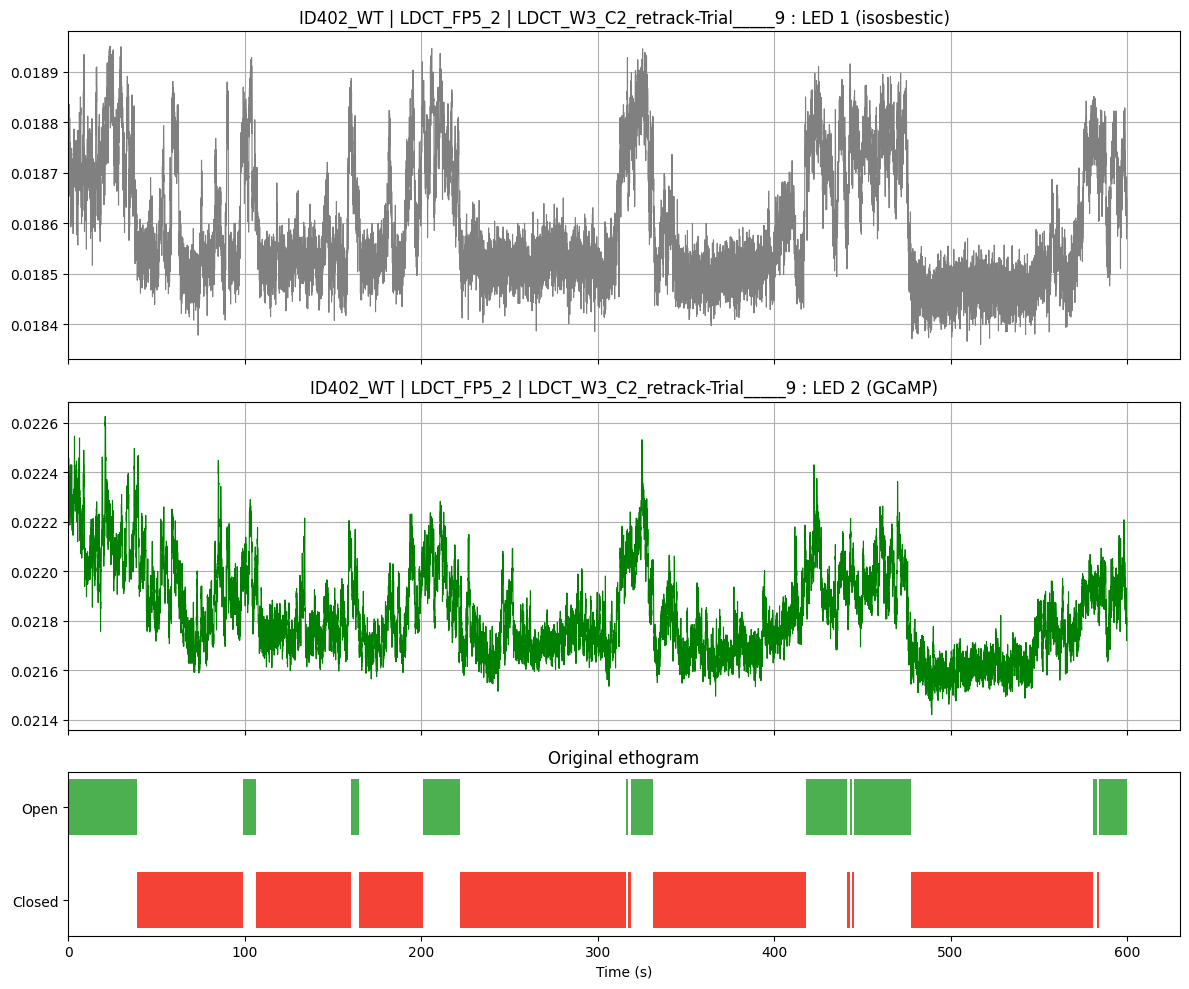

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})


def zone_color(beh):
    if beh.lower() == "open":
        return "#4CAF50"     # greenish for open
    elif beh.lower() == "closed":
        return "#F44336"     # reddish for closed
    else:
        return "gray"        # fallback


# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)


# --- Original ethogram ---
beh_cols_orig = timeline["Behavior"].unique()

for i, beh in enumerate(beh_cols_orig):
    color = zone_color(beh)     # <--- HERE
    subset = timeline[timeline["Behavior"] == beh]

    for _, row in subset.iterrows():
        axes[2].barh(
            i,
            row["Duration_s"],
            left=row["Start_time_s"],
            height=0.6,
            color=color
        )

axes[2].set_yticks(range(len(beh_cols_orig)))
axes[2].set_yticklabels(beh_cols_orig)
axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")


# # --- Original ethogram ---
# beh_cols_orig = timeline["Behavior"].unique()
# for i, beh in enumerate(beh_cols_orig):
#     color = _guess_zone_color(beh)
#     subset = timeline[timeline["Behavior"] == beh]
#     for _, row in subset.iterrows():
#         axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

# axes[2].set_yticks(range(len(beh_cols_orig)))
# axes[2].set_yticklabels(beh_cols_orig)
# axes[2].invert_yaxis()
# axes[2].set_xlabel("Time (s)")
# axes[2].set_title("Original ethogram")

# --- Cleaned / collapsed ethogram ---
#beh_cols_clean = timeline_cleaned["Behavior"].unique()
#for i, beh in enumerate(beh_cols_clean):<
#    color = _guess_zone_color(beh)
#    subset = timeline_cleaned[timeline_cleaned["Behavior"] == beh]
#    for _, row in subset.iterrows():
#        axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)
#
#axes[3].set_yticks(range(len(beh_cols_clean)))
#axes[3].set_yticklabels(beh_cols_clean)
#axes[3].invert_yaxis()
#axes[3].set_xlabel("Time (s)")
#axes[3].set_title("Collapsed + cleaned ethogram")

plt.tight_layout()
plt.show()


In [8]:
timeline_filter = timeline
timeline_filter # not needed but just doign renaming to be in line with EPM, where we did not want to include overall arena time in the processing, but since that is all we have here, it should be included - but we might need to have 1 for arena time, but also a 1 for dark chamber time

,Behavior,Start_time_s,End_time_s,Duration_s
0,Open,0.000,38.852,38.852
1,Closed,38.852,99.270,60.418
2,Open,99.270,106.332,7.062
3,Closed,106.332,160.428,54.096
4,Open,160.428,164.929,4.501
5,Closed,164.929,195.679,30.750
6,Open,195.679,195.879,0.200
7,Closed,195.879,200.860,4.981
8,Open,200.860,222.187,21.327
9,Closed,222.187,315.875,93.688


In [9]:
def smoothing_kernel(data, grainularity = 0.1, kernel_size = 5):
    """
    Smooths timeline data using a kernel.

    Args:
        data (pd.DataFrame): Timeline data.
        grainularity (float): The grainularity that the timeline data should be split up with (seconds).
        kernel_size (int): The number of 'frames' (defined by the grainularity) the kernel looks ahead 
        and behind when determining the new lable.

    Returns:
        pd.DataFrame: The timeline data reassembled with the new labels in the column 'kernel_label'.
    """
    timeline_exploded = pd.DataFrame({'timestamp' : [], 'label' : []})

    #def explode_timeline(timeline, grainularity):
    for _, row in data.iterrows():
        # timestamps = np.arange(row['Start_time_s'], row['End_time_s'], grainularity)
        timestamps = np.arange(row['Start_time_s'], row['End_time_s'] + grainularity, grainularity)

        labels = row['Behavior'] #* len(timestamps)

        timeline_exploded = pd.concat([timeline_exploded, 
                                       pd.DataFrame({'timestamp' : timestamps, 'label' : labels})])

    timeline_exploded = timeline_exploded.reset_index()

    kernel_content = []

    def most_common(lst):
        return max(set(lst), key=lst.count)

    new_labels = []

    for i, row in timeline_exploded.iterrows():
        if i < kernel_size:
            kernel_content = timeline_exploded[ : i + kernel_size]['label']

        elif i + kernel_size > len(timeline_exploded):
            kernel_content = timeline_exploded[i - (kernel_size - 1) : ]['label']

        else:
            kernel_content = timeline_exploded[i - (kernel_size - 1) : i + kernel_size]['label']
        
        new_labels.append(most_common(kernel_content.to_list()))

    timeline_exploded['kernel_label'] = new_labels

    current_label = ''

    timeline_kernel_labels = pd.DataFrame()

    # for i, row in timeline_exploded.iterrows():
    #     if current_label == row['kernel_label']:
    #         pass

    #     elif current_label == '':
    #         current_label = row['kernel_label']
    #         Start_time_s = row['timestamp']

    #     elif current_label != row['kernel_label']:
    #         timeline_kernel_labels = pd.concat([timeline_kernel_labels,
    #                                             pd.DataFrame({
    #                                                 'Behavior' : [current_label],
    #                                                 'Start_time_s' : [Start_time_s],
    #                                                 'End_time_s' : row['timestamp'],
    #                                                 'Duration_s' : row['timestamp'] - Start_time_s
    #                                             })])
    #         Start_time_s = row['timestamp']
    #         current_label = row['kernel_label']
    
    # After your existing loop that builds timeline_kernel_labels
    for i, row in timeline_exploded.iterrows():
        if current_label == row['kernel_label']:
            pass
        elif current_label == '':
            current_label = row['kernel_label']
            Start_time_s = row['timestamp']
        elif current_label != row['kernel_label']:
            timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                                pd.DataFrame({
                                                    'Behavior' : [current_label],
                                                    'Start_time_s' : [Start_time_s],
                                                    'End_time_s' : row['timestamp'],
                                                    'Duration_s' : row['timestamp'] - Start_time_s
                                                })])
            Start_time_s = row['timestamp']
            current_label = row['kernel_label']

    # --- Append the final segment ---
    if current_label != '':
        timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                            pd.DataFrame({
                                                'Behavior': [current_label],
                                                'Start_time_s': [Start_time_s],
                                                'End_time_s': [timeline_exploded['timestamp'].iloc[-1]],
                                                'Duration_s': [timeline_exploded['timestamp'].iloc[-1] - Start_time_s]
                                            })])
   # code for removing anything shorter than 1 s
    # --- Append the final segment ---
    if current_label != '':
        timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                            pd.DataFrame({
                                                'Behavior': [current_label],
                                                'Start_time_s': [Start_time_s],
                                                'End_time_s': [timeline_exploded['timestamp'].iloc[-1]],
                                                'Duration_s': [timeline_exploded['timestamp'].iloc[-1] - Start_time_s]
                                            })])

    # --- FILTER: Remove segments shorter than 1 second ---
    timeline_kernel_labels = timeline_kernel_labels[timeline_kernel_labels['Duration_s'] >= 1.0].reset_index(drop=True)



    return timeline_kernel_labels

timeline_filter = timeline[timeline['Behavior']  != 'In zone(Arena / Nose-point)'].sort_values('Start_time_s')
timeline_filter
timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity = 0.1, kernel_size = 50) #when granulairty is 0.1, it says every frame represents 0.1 second. the smaller granulairty, the less the end pieces weigh in the decision to what behaviour is being conducted




In [10]:
timeline_kernel_labels

,Behavior,Start_time_s,End_time_s,Duration_s
0,Open,0.000,38.852,38.852
1,Closed,38.852,99.270,60.418
2,Open,99.270,106.332,7.062
3,Closed,106.332,200.860,94.528
4,Open,200.860,222.187,21.327
5,Closed,222.187,318.335,96.148
6,Open,318.335,331.459,13.124
7,Closed,331.459,418.065,86.606
8,Open,418.065,477.403,59.338
9,Closed,477.403,581.874,104.471


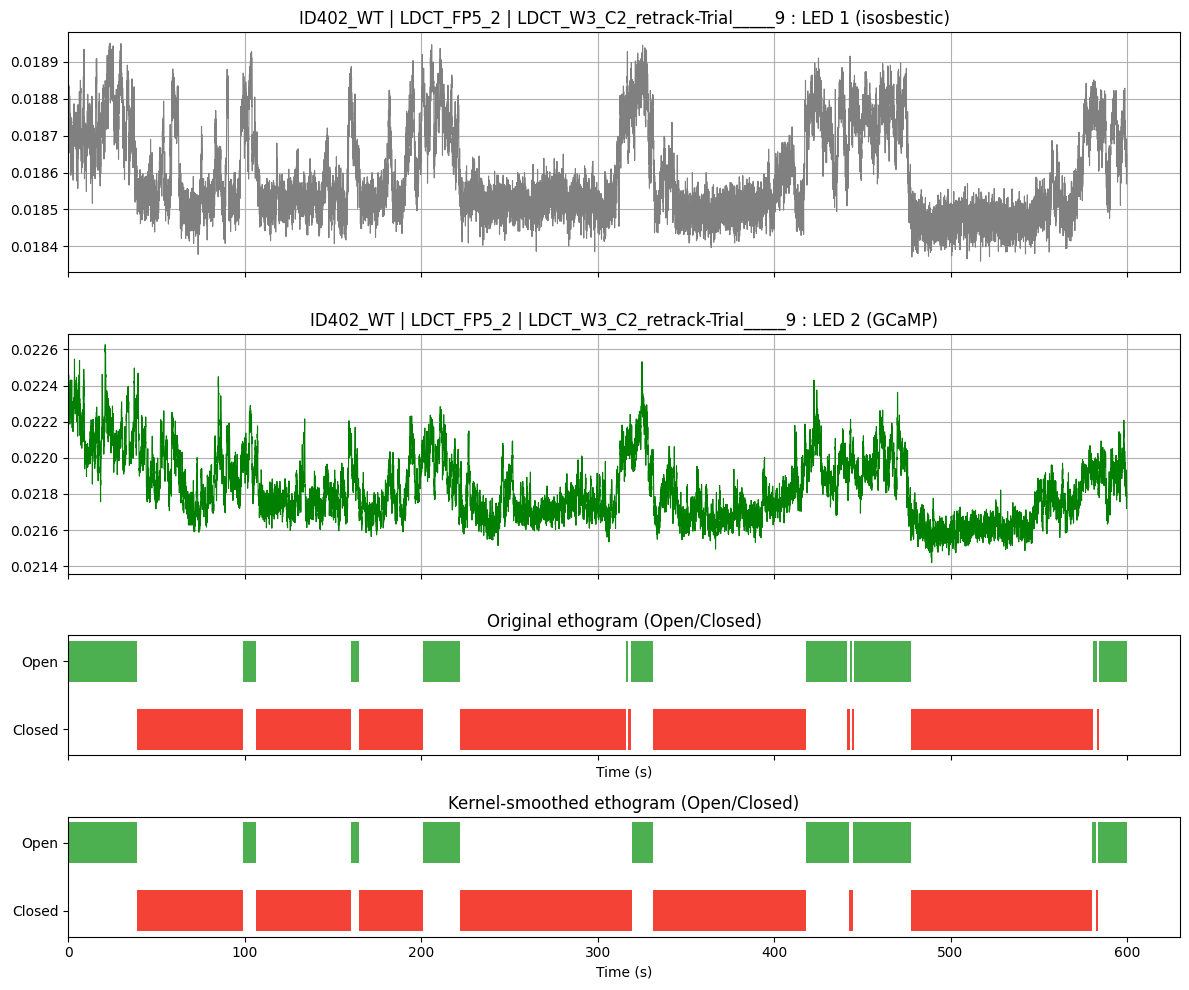

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1, 1]})

# --- Helper function for zone colors ---
def zone_color(beh):
    if beh.lower() == "open":
        return "#4CAF50"  # greenish for open
    elif beh.lower() == "closed":
        return "#F44336"  # reddish for closed
    else:
        return "gray"     # fallback

# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)

# --- Original ethogram ---
beh_cols_orig = timeline["Behavior"].unique()
for i, beh in enumerate(beh_cols_orig):
    color = zone_color(beh)
    subset = timeline[timeline["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[2].set_yticks(range(len(beh_cols_orig)))
axes[2].set_yticklabels(beh_cols_orig)
axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram (Open/Closed)")

# --- Kernel-smoothed ethogram ---
# Make sure timeline_filter is correctly set
timeline_filter = timeline.copy()  # include all segments
timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)

beh_cols_clean = timeline_kernel_labels["Behavior"].unique()
for i, beh in enumerate(beh_cols_clean):
    color = zone_color(beh)
    subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[3].set_yticks(range(len(beh_cols_clean)))
axes[3].set_yticklabels(beh_cols_clean)
axes[3].invert_yaxis()
axes[3].set_xlabel("Time (s)")
axes[3].set_title("Kernel-smoothed ethogram (Open/Closed)")

plt.tight_layout()
plt.show()


In [12]:
# sanity check - number of entries into different zones

# --- Count occurrences for each behavior in this kernel-smoothed ethogram ---
print("\nKernel-smoothed ethogram occurrences (as plotted):")

for beh in beh_cols_clean:
    subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
    n_occurrences = len(subset)
    print(f"{beh}: {n_occurrences} instance(s)")

    # Optional: print detailed start/end/duration
    for idx, row in subset.iterrows():
        print(f"  Start: {row['Start_time_s']:.3f}, "
              f"End: {row['End_time_s']:.3f}, "
              f"Duration: {row['Duration_s']:.3f}")



Kernel-smoothed ethogram occurrences (as plotted):
Open: 10 instance(s)
  Start: 0.000, End: 38.852, Duration: 38.852
  Start: 99.270, End: 106.332, Duration: 7.062
  Start: 160.428, End: 164.929, Duration: 4.501
  Start: 200.860, End: 222.187, Duration: 21.327
  Start: 319.396, End: 331.459, Duration: 12.063
  Start: 418.065, End: 442.592, Duration: 24.527
  Start: 444.733, End: 477.403, Duration: 32.670
  Start: 580.314, End: 582.715, Duration: 2.401
  Start: 583.755, End: 600.055, Duration: 16.300
  Start: 583.755, End: 600.055, Duration: 16.300
Closed: 8 instance(s)
  Start: 38.852, End: 99.270, Duration: 60.418
  Start: 106.332, End: 160.428, Duration: 54.096
  Start: 164.929, End: 200.860, Duration: 35.931
  Start: 222.187, End: 319.396, Duration: 97.209
  Start: 331.459, End: 418.065, Duration: 86.606
  Start: 442.592, End: 444.733, Duration: 2.141
  Start: 477.403, End: 580.314, Duration: 102.911
  Start: 582.715, End: 583.755, Duration: 1.040


In [13]:
print(timeline_kernel_labels) # check around 455, there are smoe very short instances

   Behavior  Start_time_s  End_time_s  Duration_s
0      Open         0.000      38.852      38.852
1    Closed        38.852      99.270      60.418
2      Open        99.270     106.332       7.062
3    Closed       106.332     160.428      54.096
4      Open       160.428     164.929       4.501
5    Closed       164.929     200.860      35.931
6      Open       200.860     222.187      21.327
7    Closed       222.187     319.396      97.209
8      Open       319.396     331.459      12.063
9    Closed       331.459     418.065      86.606
10     Open       418.065     442.592      24.527
11   Closed       442.592     444.733       2.141
12     Open       444.733     477.403      32.670
13   Closed       477.403     580.314     102.911
14     Open       580.314     582.715       2.401
15   Closed       582.715     583.755       1.040
16     Open       583.755     600.055      16.300
17     Open       583.755     600.055      16.300


# generate the above plot for all trials

first generate the open and closed zones for all the data

In [14]:
# def ethogram_to_open_closed(timeline_df, col="In Zone"):
#     """
#     Converts the timeline DataFrame produced by _ethogram_segments
#     into full 'Open' / 'Closed' segments for plotting or smoothing.

#     Args:
#         timeline_df (pd.DataFrame): Output from _ethogram_segments, with 'Start_time_s' and 'End_time_s'
#         col (str): Name of the original behavior column (default 'In Zone')

#     Returns:
#         pd.DataFrame: Timeline with alternating 'Open' and 'Closed' segments
#     """
#     if timeline_df.empty:
#         return pd.DataFrame(columns=["Behavior", "Start_time_s", "End_time_s", "Duration_s"])

#     timeline = []

#     # Start from the beginning of recording
#     t_start = timeline_df["Start_time_s"].min()
#     t_end = timeline_df["End_time_s"].max()

#     last_end = t_start

#     for _, row in timeline_df.iterrows():
#         if row["Start_time_s"] > last_end:
#             # Closed segment in the gap
#             timeline.append({
#                 "Behavior": "Closed",
#                 "Start_time_s": float(last_end),
#                 "End_time_s": float(row["Start_time_s"]),
#                 "Duration_s": float(row["Start_time_s"] - last_end)
#             })
#         # Open segment
#         timeline.append({
#             "Behavior": "Open",
#             "Start_time_s": float(row["Start_time_s"]),
#             "End_time_s": float(row["End_time_s"]),
#             "Duration_s": float(row["End_time_s"] - row["Start_time_s"])
#         })
#         last_end = row["End_time_s"]

#     # If the last segment does not reach the end of recording
#     if last_end < t_end:
#         timeline.append({
#             "Behavior": "Closed",
#             "Start_time_s": float(last_end),
#             "End_time_s": float(t_end),
#             "Duration_s": float(t_end - last_end)
#         })

#     return pd.DataFrame(timeline).sort_values("Start_time_s").reset_index(drop=True)


In [15]:
# def ethogram_to_open_closed(
#     timeline_df,
#     col=None,  # <- keeps backward compatibility
#     recording_start=0,
#     recording_end=None
# ):
#     """
#     Converts open-zone segments into a full Open/Closed ethogram.
#     """

#     if timeline_df.empty:
#         return pd.DataFrame(columns=["Behavior", "Start_time_s", "End_time_s", "Duration_s"])

#     timeline_df = timeline_df.sort_values("Start_time_s").reset_index(drop=True)

#     if recording_end is None:
#         raise ValueError("recording_end must be provided")

#     timeline = []
#     last_end = recording_start

#     for _, row in timeline_df.iterrows():
#         start = row["Start_time_s"]
#         end = row["End_time_s"]

#         # Closed gap
#         if start > last_end:
#             timeline.append({
#                 "Behavior": "Closed",
#                 "Start_time_s": float(last_end),
#                 "End_time_s": float(start),
#                 "Duration_s": float(start - last_end)
#             })

#         # Open segment
#         timeline.append({
#             "Behavior": "Open",
#             "Start_time_s": float(start),
#             "End_time_s": float(end),
#             "Duration_s": float(end - start)
#         })

#         last_end = end

#     # Final closed segment
#     if last_end < recording_end:
#         timeline.append({
#             "Behavior": "Closed",
#             "Start_time_s": float(last_end),
#             "End_time_s": float(recording_end),
#             "Duration_s": float(recording_end - last_end)
#         })

#     return pd.DataFrame(timeline).sort_values("Start_time_s").reset_index(drop=True)

In [16]:
def ethogram_to_open_closed(
    timeline_df,
    col=None,  # keeps backward compatibility
    recording_start=None,
    recording_end=None,
    fp_time_vector=None
):
    """
    Converts open-zone segments into a full Open/Closed ethogram
    that fully covers the FP time vector.

    Args:
        timeline_df (pd.DataFrame): Output from _ethogram_segments,
                                    must have 'Start_time_s' and 'End_time_s'.
        col (str, optional): Original behavior column (ignored here, for compatibility).
        recording_start (float, optional): Start time of recording. Defaults to fp_time_vector.min().
        recording_end (float, optional): End time of recording. Defaults to fp_time_vector.max().
        fp_time_vector (np.array or pd.Series, optional): Time vector of FP trace for alignment.

    Returns:
        pd.DataFrame: Timeline with columns ['Behavior', 'Start_time_s', 'End_time_s', 'Duration_s'].
    """

    # Handle empty timeline
    if timeline_df.empty:
        if fp_time_vector is not None:
            start = float(fp_time_vector.min())
            end   = float(fp_time_vector.max())
        else:
            start = 0.0
            end   = 1.0  # default dummy
        return pd.DataFrame({
            "Behavior": ["Closed"],
            "Start_time_s": [start],
            "End_time_s": [end],
            "Duration_s": [end - start]
        })

    # Sort segments
    timeline_df = timeline_df.sort_values("Start_time_s").reset_index(drop=True)

    # Determine recording start/end
    if fp_time_vector is not None:
        recording_start = float(fp_time_vector.min())
        recording_end   = float(fp_time_vector.max())
    else:
        if recording_start is None or recording_end is None:
            recording_start = float(timeline_df["Start_time_s"].min())
            recording_end   = float(timeline_df["End_time_s"].max())

    timeline = []
    last_end = recording_start

    for _, row in timeline_df.iterrows():
        start = float(row["Start_time_s"])
        end   = float(row["End_time_s"])

        # Closed gap before this open segment
        if start > last_end:
            timeline.append({
                "Behavior": "Closed",
                "Start_time_s": last_end,
                "End_time_s": start,
                "Duration_s": start - last_end
            })

        # Open segment
        timeline.append({
            "Behavior": "Open",
            "Start_time_s": start,
            "End_time_s": end,
            "Duration_s": end - start
        })

        last_end = end

    # Final closed segment to cover the rest of recording
    if last_end < recording_end:
        timeline.append({
            "Behavior": "Closed",
            "Start_time_s": last_end,
            "End_time_s": recording_end,
            "Duration_s": recording_end - last_end
        })

    df = pd.DataFrame(timeline)

    # Normalize behavior strings for safety
    df["Behavior"] = df["Behavior"].astype(str).str.strip().str.title()

    return df.sort_values("Start_time_s").reset_index(drop=True)

In [17]:
# # ==========================================================
# # Preprocess all trials into open/closed timeline segments
# # ==========================================================
# for trial_key, trial_data in fp_traces.items():
#     try:
#         # Use the timeline already generated by _ethogram_segments
#         segs = ethogram_to_open_closed(trial_data["timeline"], col="In Zone")
#         trial_data["timeline_open_closed"] = segs
#         trial_data["beh_cols_open_closed"] = segs["Behavior"].unique()

#     except Exception as e:
#         print(f"[WARN] Could not preprocess trial {trial_key}: {e}")


In [18]:
for trial_key, trial_data in fp_traces.items():
    try:
        iso_df = trial_data["iso"]
        gcamp_df = trial_data["gcamp"]

        # --- Compute recording duration ---
        recording_end = max(
            iso_df["Time_video"].max(),
            gcamp_df["Time_video"].max()
        )

        # --- Convert to full Open/Closed ethogram ---
        segs = ethogram_to_open_closed(
            trial_data["timeline"],
            col="In Zone",          # harmless now (kept for compatibility)
            recording_start=0,
            recording_end=recording_end
        )

        trial_data["timeline_open_closed"] = segs
        trial_data["beh_cols_open_closed"] = segs["Behavior"].unique()

    except Exception as e:
        print(f"[WARN] Could not preprocess trial {trial_key}: {e}")

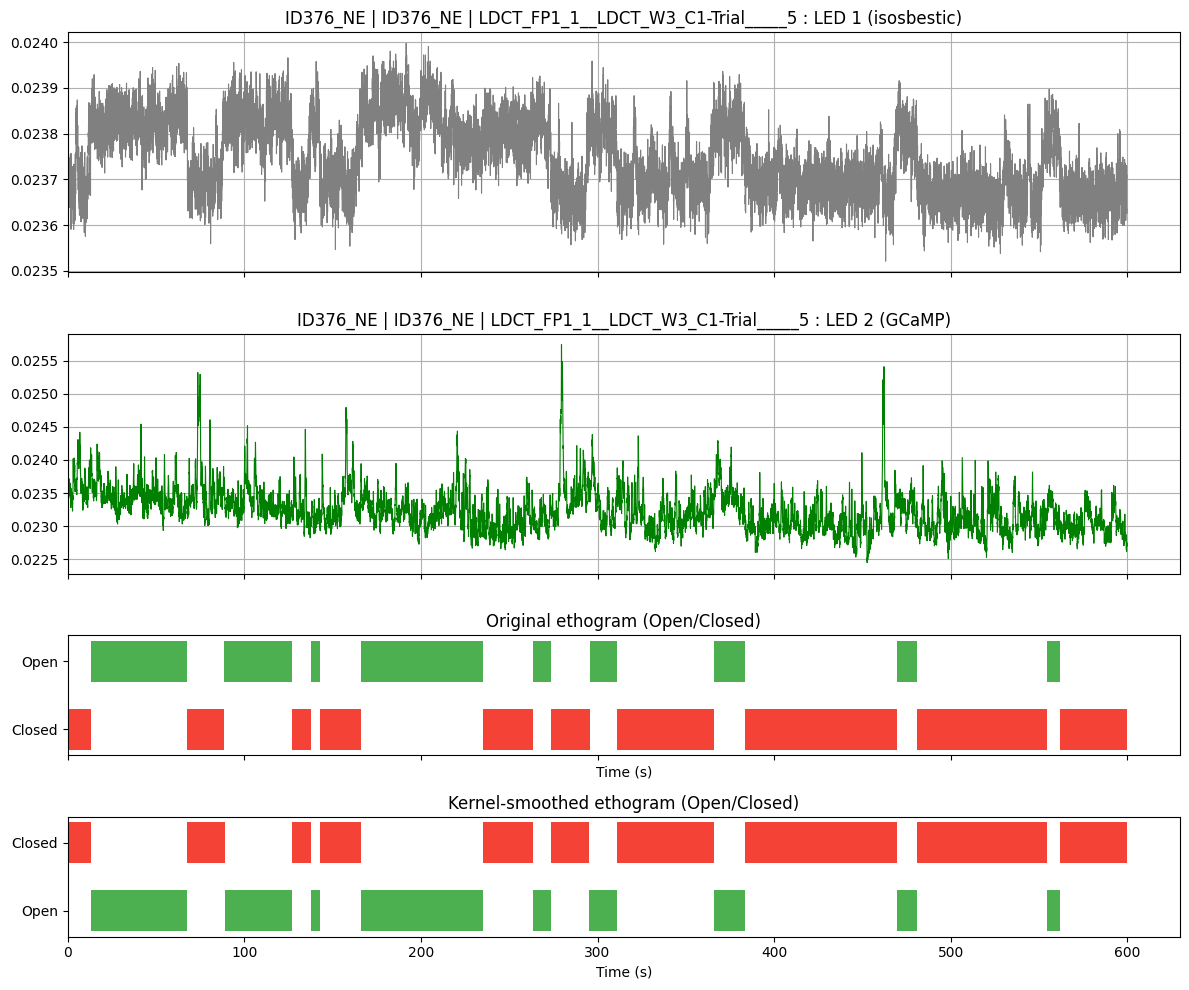

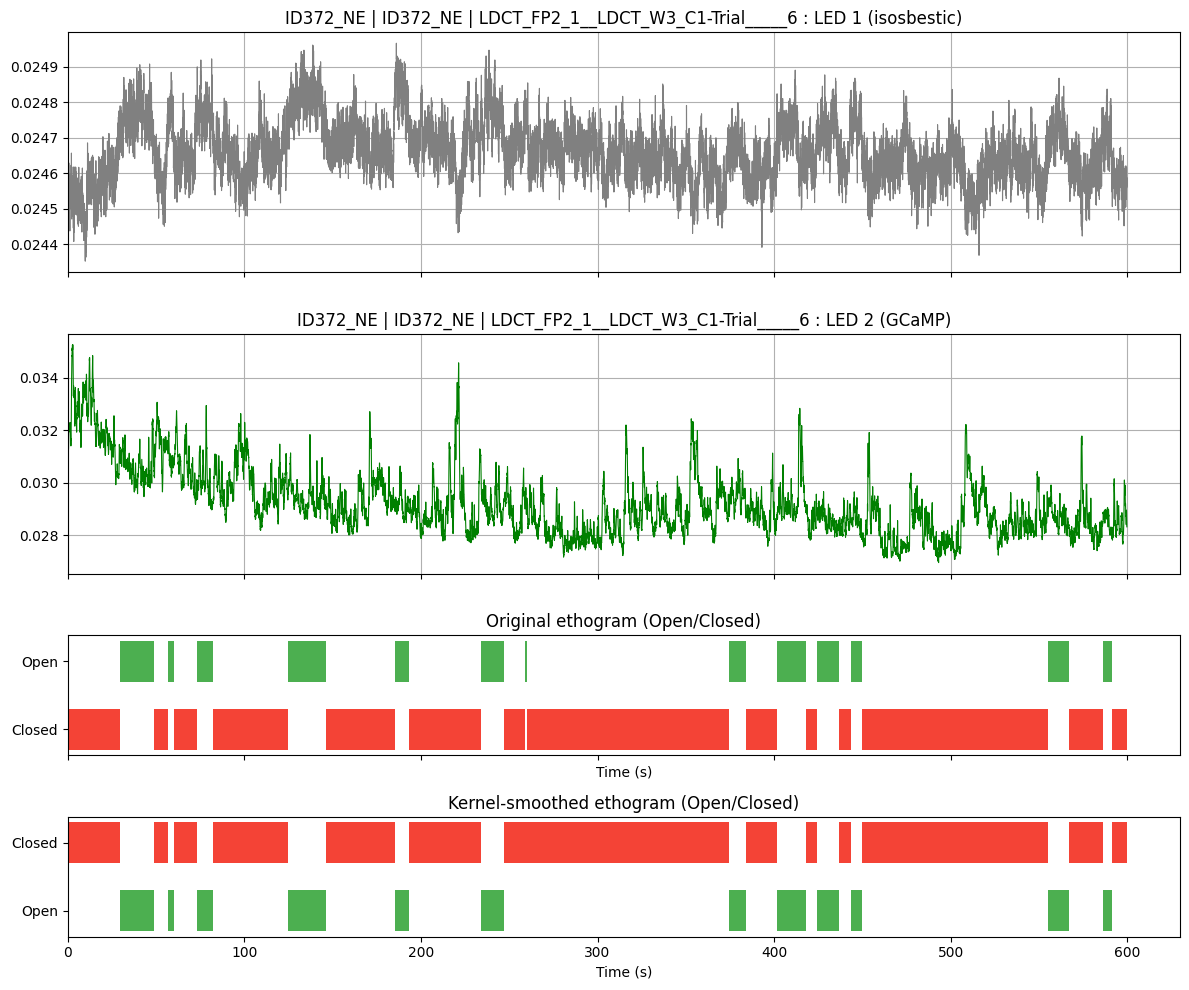

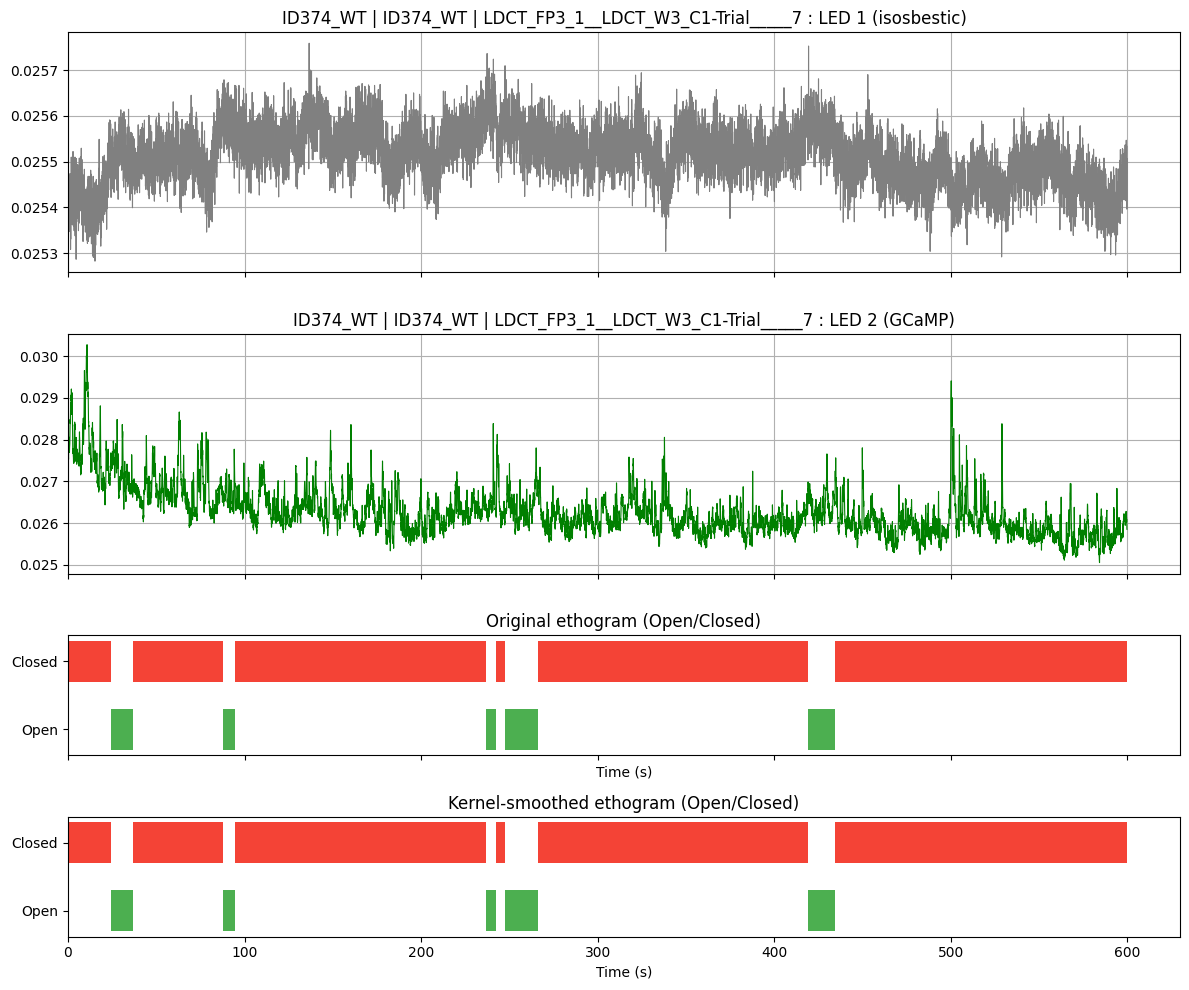

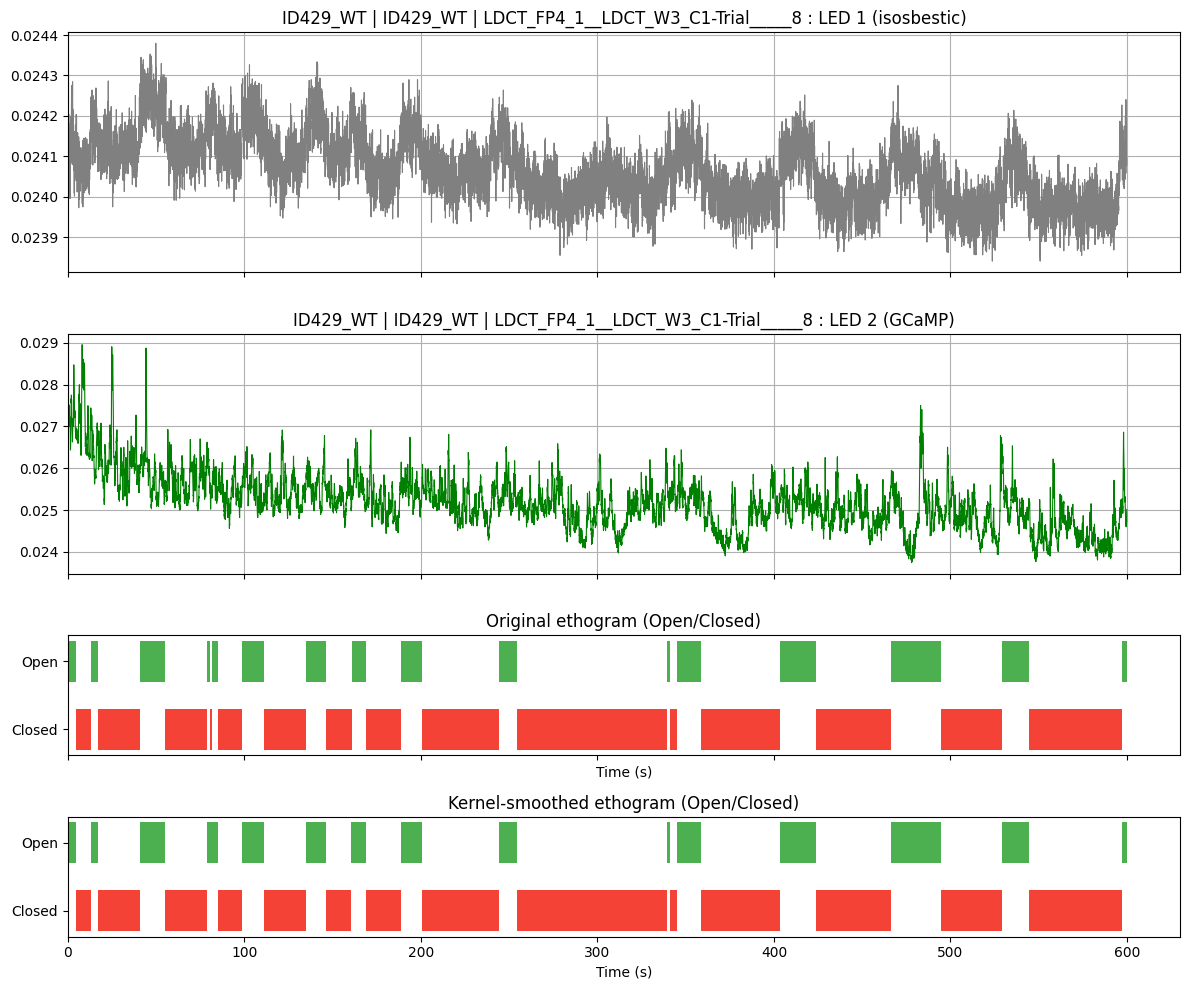

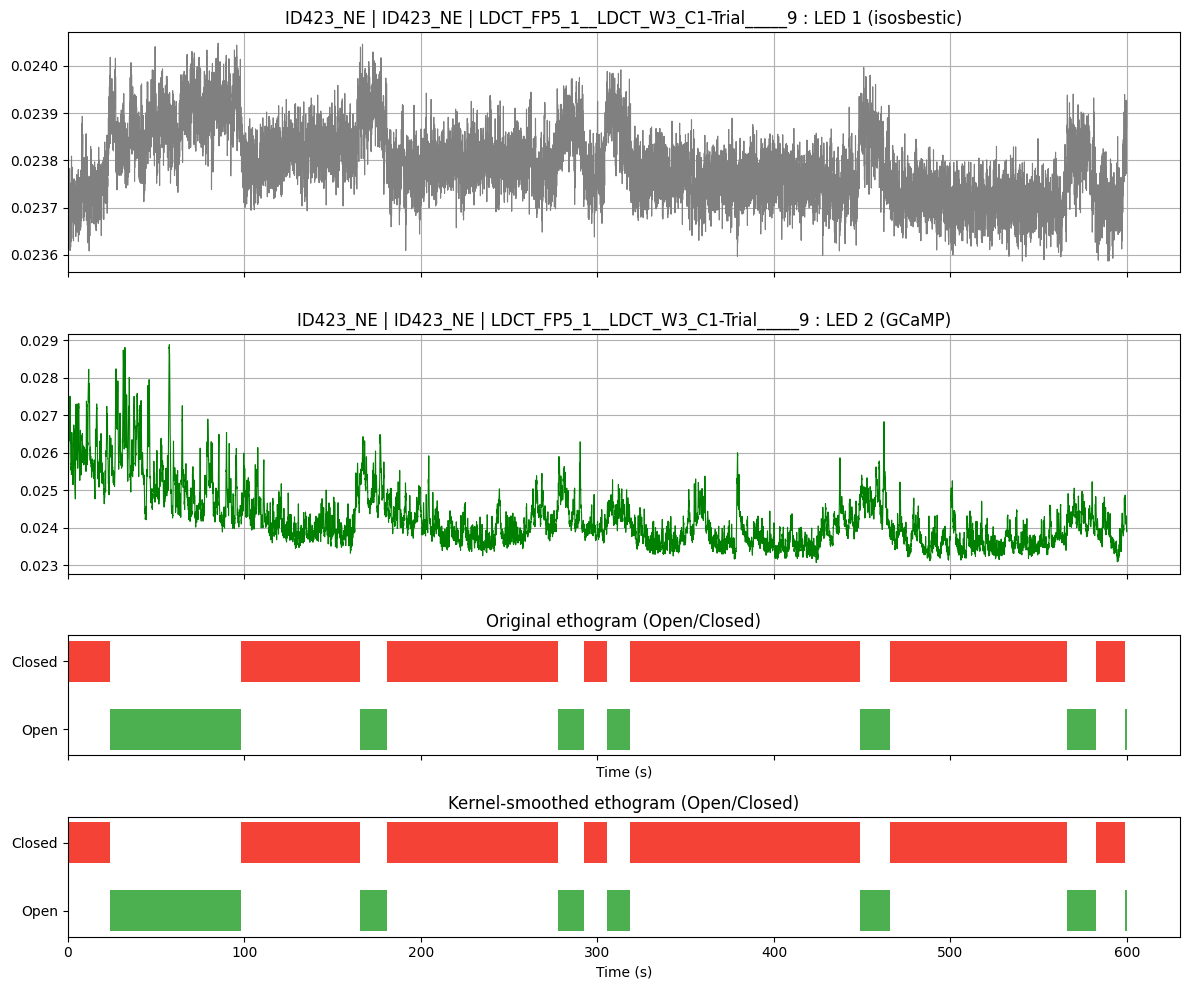

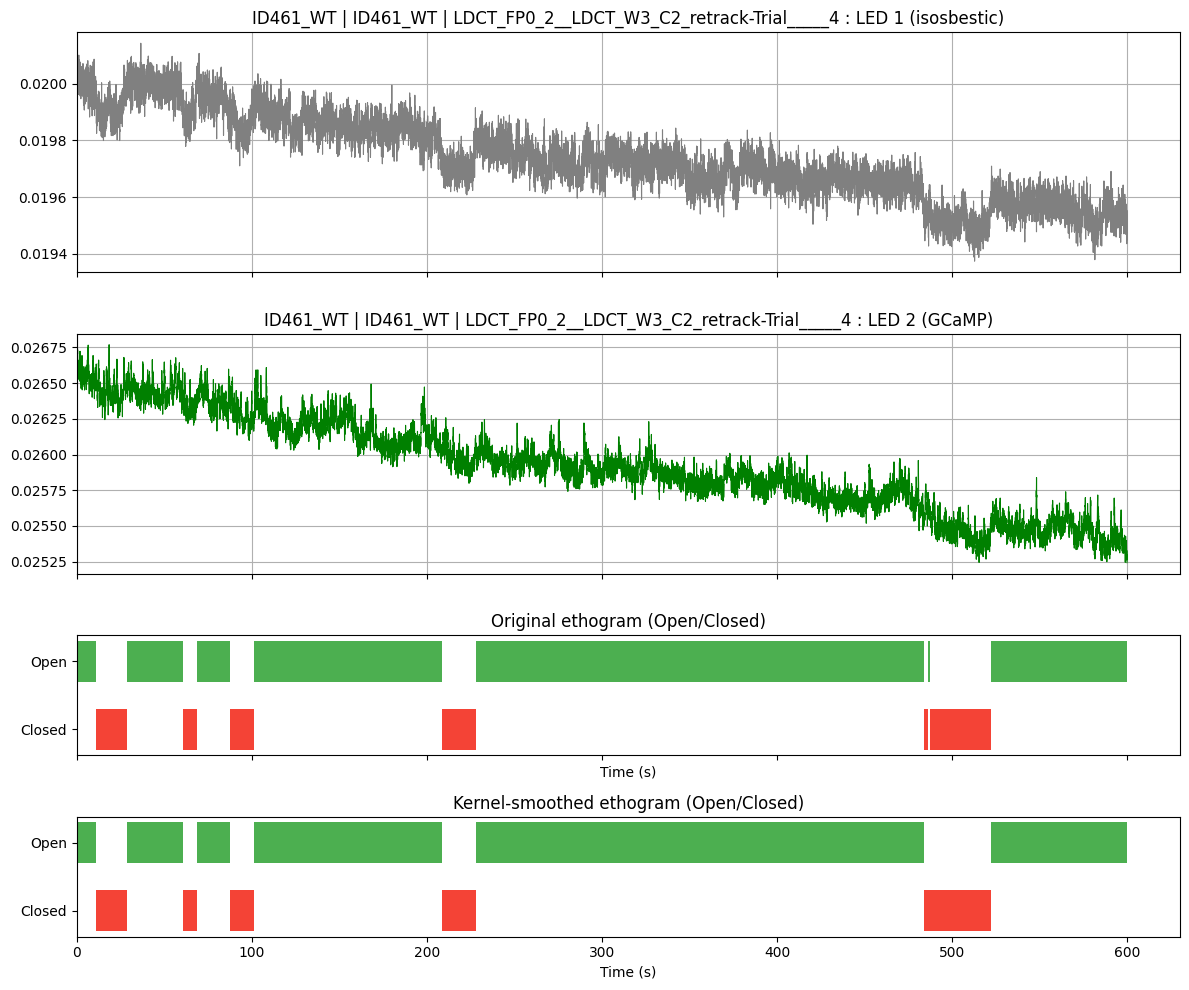

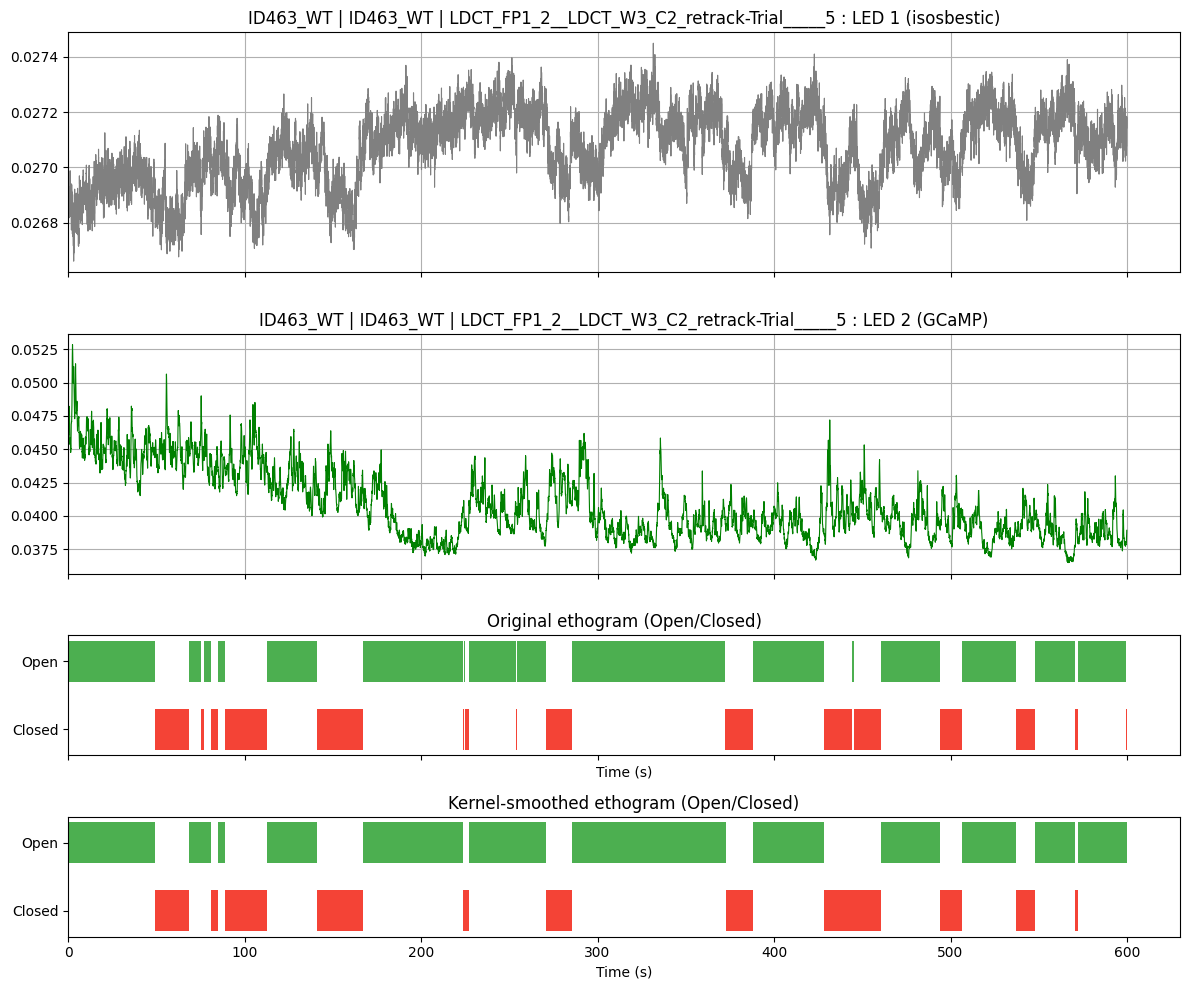

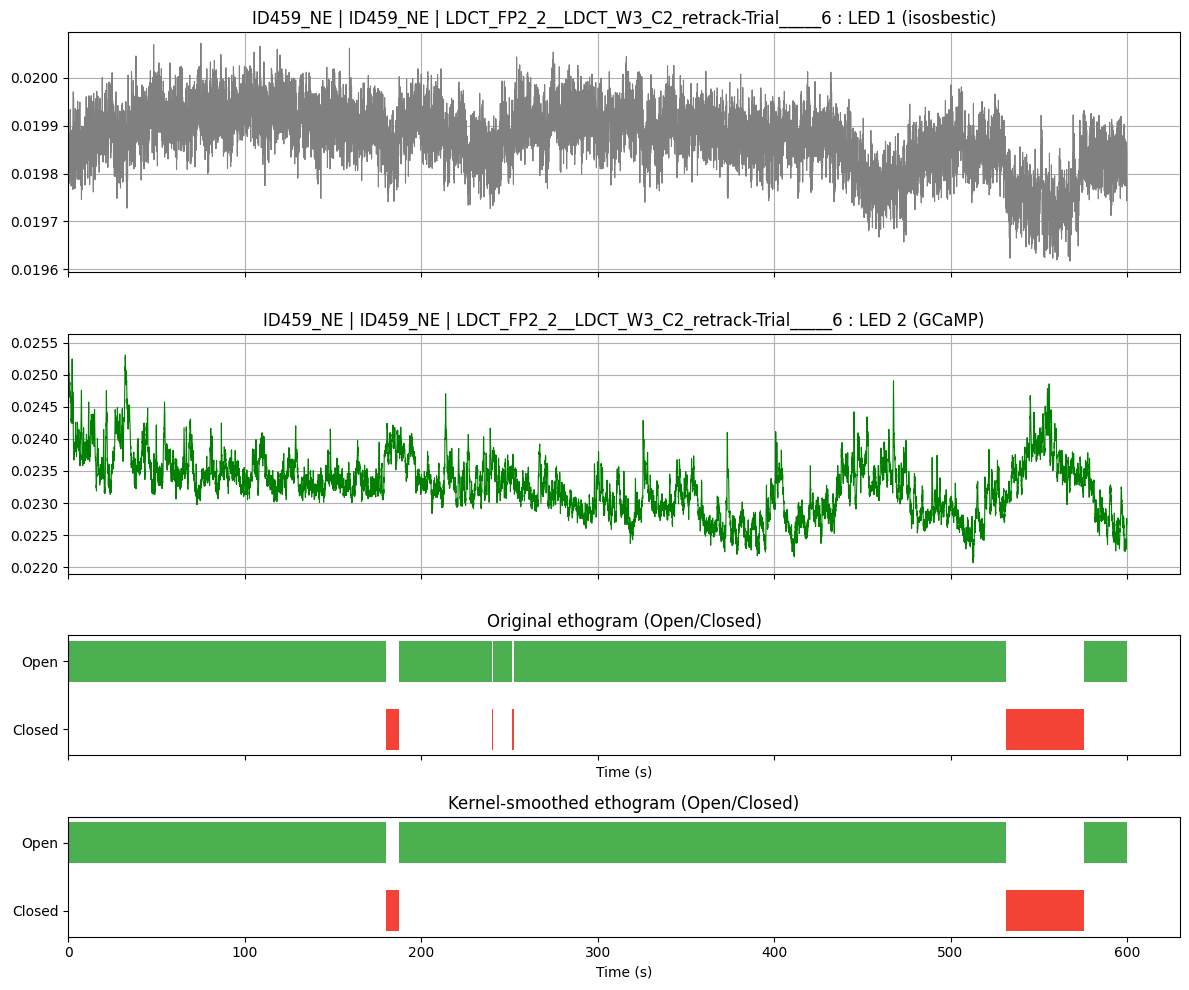

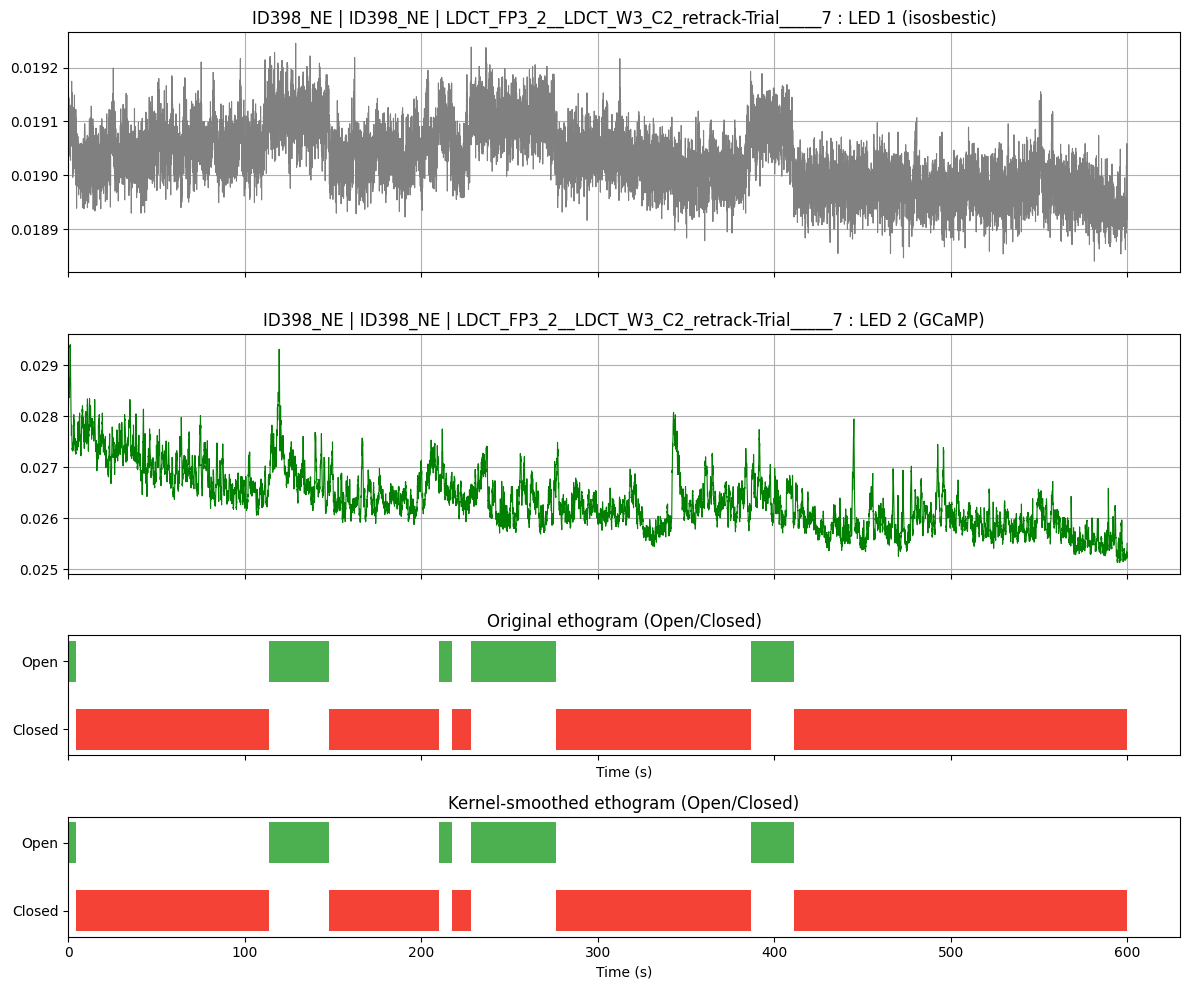

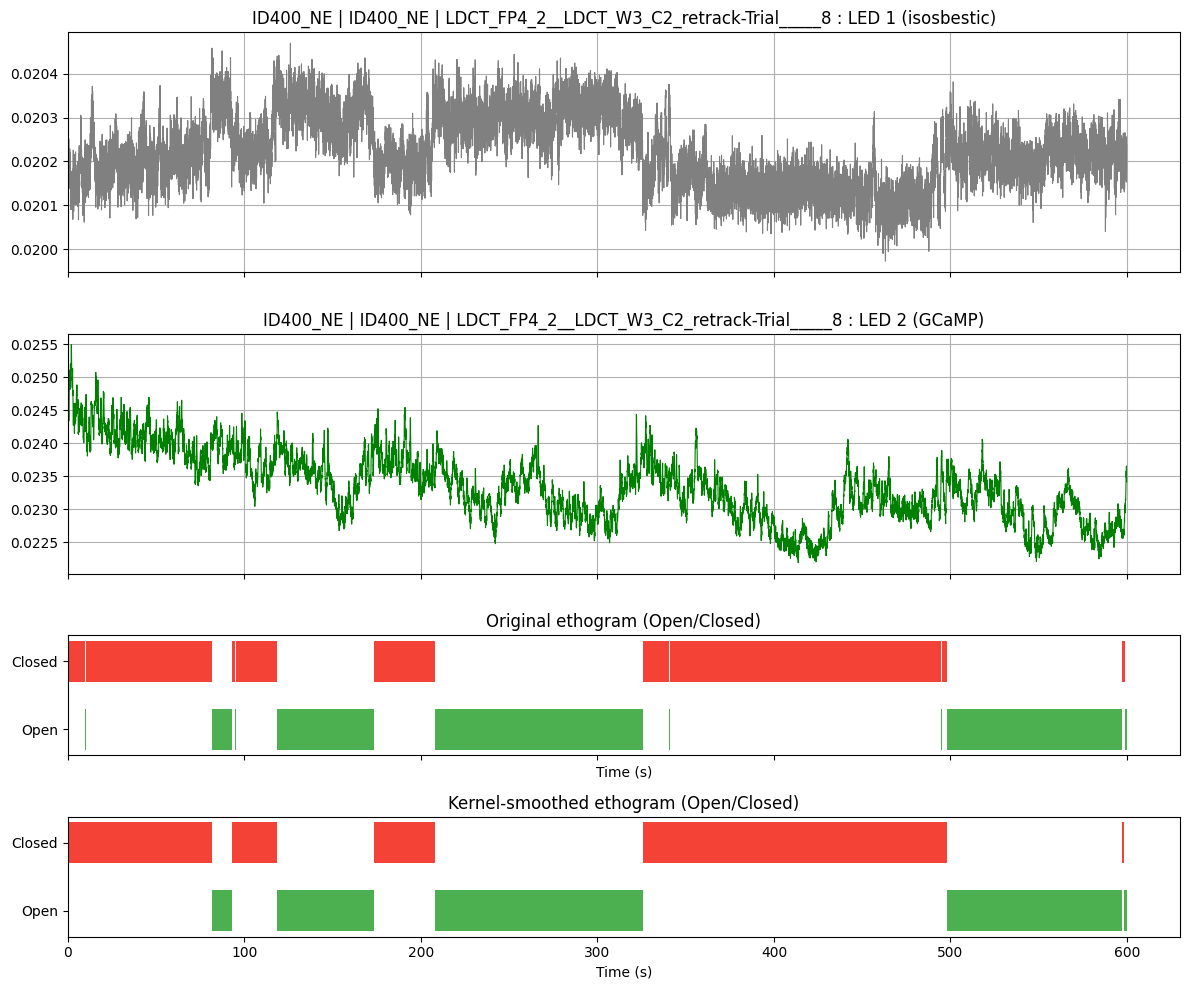

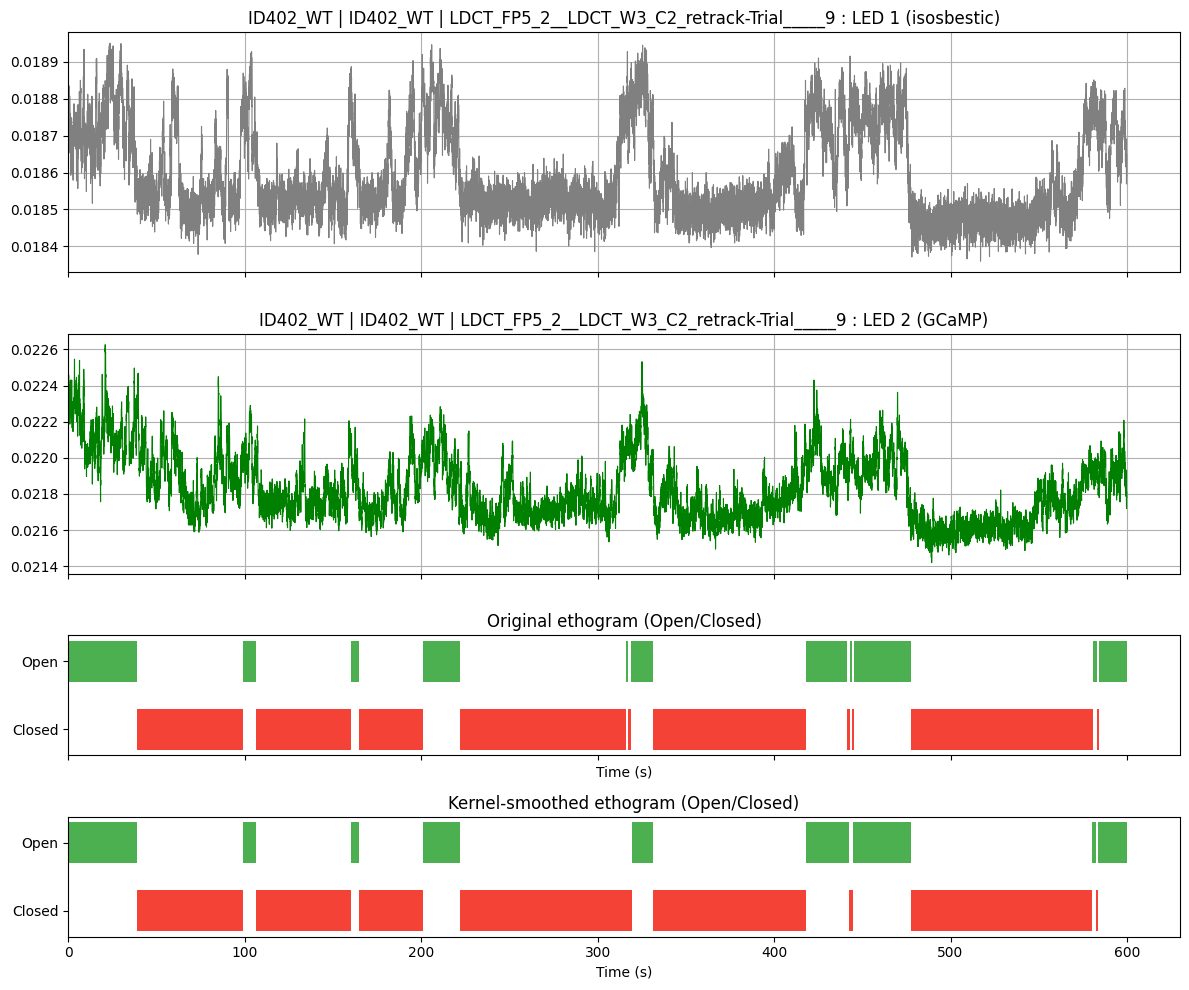

In [19]:
# ==========================================================
# Apply smoothing_kernel and plot kernel-smoothed ethograms for all trials
# ==========================================================

for trial_key, trial_data in fp_traces.items():
    try:
        # Extract FP traces and timeline
        iso_df = trial_data["iso"]
        gcamp_df = trial_data["gcamp"]
        #timeline = trial_data["timeline"]
        timeline = trial_data["timeline_open_closed"]
        mouse_label = f"ID{trial_data['mouse_id']}" + (f"_{trial_data['genotype']}" if trial_data['genotype'] else "")
        fp_id = trial_key.split("__")[1]
        trial_stub = "__".join(trial_key.split("__")[2:])

        # --- Filter timeline (optional: exclude arena if needed) ---
        timeline_filter = timeline.copy()  # include all segments

        # --- Apply smoothing kernel ---
        timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)
        trial_data["timeline_kernel"] = timeline_kernel_labels  # store for later

        # --- Create figure ---
        fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 2, 1, 1]})

        # --- Helper function for zone colors ---
        def zone_color(beh):
            if beh.lower() == "open":
                return "#4CAF50"  # greenish
            elif beh.lower() == "closed":
                return "#F44336"  # reddish
            else:
                return "gray"     # fallback

        # --- FP traces ---
        iso_col = [c for c in iso_df.columns if c != "Time_video"][0]
        gcamp_col = [c for c in gcamp_df.columns if c != "Time_video"][0]

        axes[0].plot(iso_df["Time_video"], iso_df[iso_col], linewidth=0.8, color="gray")
        axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
        axes[0].grid(True)

        axes[1].plot(gcamp_df["Time_video"], gcamp_df[gcamp_col], linewidth=0.8, color="green")
        axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
        axes[1].grid(True)

        # --- Original ethogram ---
        beh_cols_orig = timeline["Behavior"].unique()
        for i, beh in enumerate(beh_cols_orig):
            color = zone_color(beh)
            subset = timeline[timeline["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        axes[2].set_yticks(range(len(beh_cols_orig)))
        axes[2].set_yticklabels(beh_cols_orig)
        axes[2].invert_yaxis()
        axes[2].set_xlabel("Time (s)")
        axes[2].set_title("Original ethogram (Open/Closed)")

        # --- Kernel-smoothed ethogram ---
        beh_cols_clean = timeline_kernel_labels["Behavior"].unique()
        for i, beh in enumerate(beh_cols_clean):
            color = zone_color(beh)
            subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        axes[3].set_yticks(range(len(beh_cols_clean)))
        axes[3].set_yticklabels(beh_cols_clean)
        axes[3].invert_yaxis()
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Kernel-smoothed ethogram (Open/Closed)")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[WARN] Could not plot trial {trial_key}: {e}")


In [20]:
for trial_key, trial_data in fp_traces.items():
    print(f"\nTrial: {trial_key}")
    if "timeline_kernel" not in trial_data:
        print("  No kernel-smoothed ethogram found.")
        continue

    tk = trial_data["timeline_kernel"]

    # Count number of separate occurrences for each behavior
    counts = tk["Behavior"].value_counts()
    for beh, n in counts.items():
        print(f"  {beh}: {n} instance(s)")



Trial: W3__ID376_NE__LDCT_FP1_1__LDCT_W3_C1-Trial_____5
  Closed: 11 instance(s)
  Open: 9 instance(s)

Trial: W3__ID372_NE__LDCT_FP2_1__LDCT_W3_C1-Trial_____6
  Closed: 14 instance(s)
  Open: 12 instance(s)

Trial: W3__ID374_WT__LDCT_FP3_1__LDCT_W3_C1-Trial_____7
  Closed: 7 instance(s)
  Open: 5 instance(s)

Trial: W3__ID429_WT__LDCT_FP4_1__LDCT_W3_C1-Trial_____8
  Open: 16 instance(s)
  Closed: 14 instance(s)

Trial: W3__ID423_NE__LDCT_FP5_1__LDCT_W3_C1-Trial_____9
  Open: 8 instance(s)
  Closed: 7 instance(s)

Trial: W3__ID461_WT__LDCT_FP0_2__LDCT_W3_C2_retrack-Trial_____4
  Open: 7 instance(s)
  Closed: 5 instance(s)

Trial: W3__ID463_WT__LDCT_FP1_2__LDCT_W3_C2_retrack-Trial_____5
  Open: 13 instance(s)
  Closed: 11 instance(s)

Trial: W3__ID459_NE__LDCT_FP2_2__LDCT_W3_C2_retrack-Trial_____6
  Open: 4 instance(s)
  Closed: 2 instance(s)

Trial: W3__ID398_NE__LDCT_FP3_2__LDCT_W3_C2_retrack-Trial_____7
  Closed: 6 instance(s)
  Open: 5 instance(s)

Trial: W3__ID400_NE__LDCT_FP4_2__

In [21]:
# Get the last trial key
last_key = list(fp_traces.keys())[0]
trial_data = fp_traces[last_key]

print(f"Full kernel-smoothed timeline for trial: {last_key}\n")

if "timeline_kernel" in trial_data:
    tk = trial_data["timeline_kernel"]
    # Print all columns
    print(tk.to_string(index=False))
else:
    print("No kernel-smoothed ethogram found for this trial.")


Full kernel-smoothed timeline for trial: W3__ID376_NE__LDCT_FP1_1__LDCT_W3_C1-Trial_____5

Behavior  Start_time_s  End_time_s  Duration_s
  Closed         0.000      13.164      13.164
    Open        13.164      67.700      54.536
  Closed        67.700      88.827      21.127
    Open        88.827     126.998      38.171
  Closed       126.998     137.781      10.783
    Open       137.781     142.663       4.882
  Closed       142.663     166.130      23.467
    Open       166.130     235.010      68.880
  Closed       235.010     263.199      28.189
    Open       263.199     273.522      10.323
  Closed       273.522     295.188      21.666
    Open       295.188     311.013      15.825
  Closed       311.013     365.950      54.937
    Open       365.950     383.735      17.785
  Closed       383.735     469.601      85.866
    Open       469.601     481.224      11.623
  Closed       481.224     554.586      73.362
    Open       554.586     561.969       7.383
  Closed       5

# GUPPY PIPELINE 

# Generate plots of each trial where the FP signal is cut to the timeframe of the ethovision video, and it is plotted against an ethogram of the ethovision video

# code for manually subtracting iso from gcamp by aligning iso and gcamp to occur at same timepoints (a bit artificial, they do not occur at exactly the same timepoint)

In [22]:
# ==========================================================
# Coregister ISO and GCaMP traces for all timepoints
# ==========================================================

import pandas as pd

def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    """
    trial_traces: dict with keys 'iso' and 'gcamp', each a DataFrame like:
        iso:   ['Time_video', 'G0_iso415']
        gcamp:['Time_video', 'G0_gcamp470']

    Returns one DataFrame with:
        Time_video  (from the channel that starts first)
        iso415
        gcamp470
    """
    iso = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    # Get signal column names
    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    # Trim to common length just in case
    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    # Decide which channel is "main" based on starting time
    if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
        # gcamp starts first → use its time
        time_main = gcamp["Time_video"].values
    else:
        # iso starts first → use its time
        time_main = iso["Time_video"].values

    aligned = pd.DataFrame({
        "Time_video": time_main,
        "iso415": iso[iso_col].values,
        "gcamp470": gcamp[gcamp_col].values,
    })

    return aligned

# -------------------------------------------------
# Apply coregistration to all trials in fp_traces
# -------------------------------------------------

coregistered_traces = {}  # store results per trial

for tp in timepoints:
    # Filter keys for this timepoint
    tp_keys = [k for k in fp_traces.keys() if k.startswith(f"{tp}__")]
    for k in tp_keys:
        try:
            aligned_df = coregister_iso_gcamp(fp_traces[k])
            coregistered_traces[k] = aligned_df
        except Exception as e:
            print(f"[WARN] Could not coregister {k}: {e}")

# Example access:


In [23]:
# Show the first key
first_key = list(coregistered_traces.keys())[1]
print("First trial key:", first_key)

# Show the head of the aligned dataframe
print(coregistered_traces[first_key].head())


First trial key: W3__ID372_NE__LDCT_FP2_1__LDCT_W3_C1-Trial_____6
   Time_video    iso415  gcamp470
0        0.00  0.024688  0.031964
1        0.04  0.024607  0.031799
2        0.08  0.024647  0.031582
3        0.12  0.024643  0.031456
4        0.16  0.024601  0.031389


# apply zero-phase moving window - not using subtracted data

After extraction of the data, a zero-phase moving average linear digital filter is applied backwards and forwards to both the channels to reduce high frequency noise without time-shifting. The standard window for the moving filter is 100 data points i GuPPy, but can be adjusted by the user when setting input parameters. The window needs to be adjusted depending on the sampling rate of the recorded data. Guidelines are provided in the user guide. The traces resulting after this filtering step will be displayed for the user to inspect before proceeding with analysis.

In [24]:
import numpy as np
from scipy.signal import filtfilt

def zero_phase_moving_average(signal, window_pts=5):
    """
    GuPPy-style zero-phase moving average.
    """
    signal = np.asarray(signal, dtype=float)

    if window_pts < 1:
        raise ValueError("window_pts must be >= 1")

    kernel = np.ones(window_pts, dtype=float) / window_pts

    filtered = filtfilt(kernel, [1.0], signal, padlen=3 * window_pts)
    return filtered


# ==========================================================
# Apply zero-phase moving average to all aligned trials
# ==========================================================

smoothed_trials = {}

window_pts = 5  # ≈ 4 seconds at 25 Hz alternation

for key, df in coregistered_traces.items():     # FIXED HERE
    try:
        smoothed_df = df.copy()
        smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
        smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
        smoothed_trials[key] = smoothed_df
    except Exception as e:
        print(f"[WARN] Could not smooth trial {key}: {e}")

# Example output
example_key = list(smoothed_trials.keys())[0]
print(f"Example smoothed trial: {example_key}")
print(smoothed_trials[example_key].head())


Example smoothed trial: W3__ID376_NE__LDCT_FP1_1__LDCT_W3_C1-Trial_____5
   Time_video    iso415  gcamp470  iso415_smooth  gcamp470_smooth
0        0.00  0.023793  0.023683       0.023793         0.023683
1        0.04  0.023779  0.023604       0.023782         0.023658
2        0.08  0.023817  0.023648       0.023773         0.023639
3        0.12  0.023731  0.023584       0.023763         0.023623
4        0.16  0.023736  0.023595       0.023754         0.023608


In [25]:
# Show the first key
first_key = list(coregistered_traces.keys())[1]
print("First trial key:", first_key)

# Show the head of the aligned dataframe
print(coregistered_traces[first_key].head())


First trial key: W3__ID372_NE__LDCT_FP2_1__LDCT_W3_C1-Trial_____6
   Time_video    iso415  gcamp470
0        0.00  0.024688  0.031964
1        0.04  0.024607  0.031799
2        0.08  0.024647  0.031582
3        0.12  0.024643  0.031456
4        0.16  0.024601  0.031389


Nice, you found the key bit in their methods. That paragraph is describing what happens on the TDT rig, not in GuPPy itself:
465 nm and 405 nm LEDs … were demodulated using a 4 Hz low-pass frequency filter.
So there are actually two separate filtering stages in their setup:
Hardware / Synapse side (TDT)
LEDs modulated at ~200–330 Hz
Demodulated and low-pass filtered at 4 Hz on the RZ5P
This already strips out the fast carrier and most high-frequency noise
Software side (GuPPy)
GuPPy then adds a zero-phase moving average filter with a user-defined window (default 100 points) on the demodulated streams
The “Window for Moving Average filter” in GuPPy refers to step 2.
How to think about window_pts in terms of your sampling rate
​	
Larger M → lower cutoff → more aggressive smoothing
Smaller M → higher cutoff → lighter smoothing
What did GuPPy likely do in their own rig?
On TDT they say “demodulated using a 4 Hz low-pass filter”. If their demodulated stream was at around 1 kHz (typical for RZ5P), then:

​	
 ≈4.4 Hz
So a 100-point moving average at ~1 kHz naturally gives about a 4 Hz cutoff, which matches their description.
In your case, though, you’re working with already demultiplexed / downsampled FP3002-style traces at ~25 Hz per channel.
What is “appropriate” for 25 Hz per channel?

​	
 
Some example window_pts:
M (window_pts)	f_c (approx)	Smoothed time scale
3	~3.7 Hz	very light smoothing, almost raw
5	~2.2 Hz	light smoothing
11	~1.0 Hz	moderate smoothing over ~1 s
25	~0.44 Hz	strong smoothing over several seconds
75	~0.15 Hz	very slow trend only, kills fast dynamics

Start with window_pts = 5–11
5 points → f_c ≈ 2.2 Hz (light smoothing)
11 points → f_c ≈ 1.0 Hz (moderate smoothing)

If you want to process ISO and GCaMP separately (without merging/alignment), you can compute filtered traces only or optionally z-score each independently. ∆F/F won’t make sense without alignment, but you can still smooth and analyze each channel.

what you’re plotting is not the regression line in 2D space, but the 405 time-series passed through the regression model.

In [26]:
import numpy as np

preproc_trials = {}

for key, df in smoothed_trials.items():
    df = df.copy()

    # Take smoothed iso (control) and gcamp (signal)
    x = df["iso415_smooth"].to_numpy()
    y = df["gcamp470_smooth"].to_numpy()

    # Mask invalid values
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 2:
        print(f"[WARN] Not enough valid points for trial {key}")
        continue

    # Linear regression: y ≈ a*x + b
    a, b = np.polyfit(x_fit, y_fit, 1)

    # Fitted baseline
    Y_fit_all = a * x + b

    # Delta F
    Y_dF_all = y - Y_fit_all

    # ∆F/F (%)
    eps = np.finfo(float).eps
    dFF = 100.0 * (Y_dF_all / (Y_fit_all + eps))

    # z-scored ∆F/F
    mu  = np.nanmean(dFF)
    sig = np.nanstd(dFF)
    dFF_z = (dFF - mu)/sig if sig > 0 else np.zeros_like(dFF)

    # Store in DataFrame
    df["iso_fit"] = Y_fit_all
    df["dFF"] = dFF
    df["dFF_z"] = dFF_z

    preproc_trials[key] = df


In [27]:
# Plot preprocessed trials with fitted baseline and dF/F
for key in preproc_trials.keys():  # <-- use preproc_trials, not smoothed_trials
    try:
        plot_preproc_trial(preproc_trials[key], key)
    except Exception as e:
        print(f"[WARN] Could not plot {key}: {e}")


[WARN] Could not plot W3__ID376_NE__LDCT_FP1_1__LDCT_W3_C1-Trial_____5: name 'plot_preproc_trial' is not defined
[WARN] Could not plot W3__ID372_NE__LDCT_FP2_1__LDCT_W3_C1-Trial_____6: name 'plot_preproc_trial' is not defined
[WARN] Could not plot W3__ID374_WT__LDCT_FP3_1__LDCT_W3_C1-Trial_____7: name 'plot_preproc_trial' is not defined
[WARN] Could not plot W3__ID429_WT__LDCT_FP4_1__LDCT_W3_C1-Trial_____8: name 'plot_preproc_trial' is not defined
[WARN] Could not plot W3__ID423_NE__LDCT_FP5_1__LDCT_W3_C1-Trial_____9: name 'plot_preproc_trial' is not defined
[WARN] Could not plot W3__ID461_WT__LDCT_FP0_2__LDCT_W3_C2_retrack-Trial_____4: name 'plot_preproc_trial' is not defined
[WARN] Could not plot W3__ID463_WT__LDCT_FP1_2__LDCT_W3_C2_retrack-Trial_____5: name 'plot_preproc_trial' is not defined
[WARN] Could not plot W3__ID459_NE__LDCT_FP2_2__LDCT_W3_C2_retrack-Trial_____6: name 'plot_preproc_trial' is not defined
[WARN] Could not plot W3__ID398_NE__LDCT_FP3_2__LDCT_W3_C2_retrack-Trial

In [28]:
# Putting together corrections to ethovision ethogram and FP preprocessed traces

#below code uses all the preprocessed signals, also the intermediares + skip to the next block to see only delta F over F signal

In [29]:
def map_behavior_to_time(time_vector, timeline_kernel):
    """
    Map the kernel-smoothed behavior to each timepoint in the FP time vector.
    
    Args:
        time_vector (np.array): FP time points (Time_video)
        timeline_kernel (pd.DataFrame): Kernel-smoothed ethogram with columns
                                        ['Behavior', 'Start_time_s', 'End_time_s']
    Returns:
        np.array: Behavior label for each time point
    """
    behavior_at_time = np.array(["Unknown"] * len(time_vector), dtype=object)

    for _, row in timeline_kernel.iterrows():
        mask = (time_vector >= row["Start_time_s"]) & (time_vector < row["End_time_s"])
        behavior_at_time[mask] = row["Behavior"]

    return behavior_at_time


In [30]:
# def map_behavior_to_time(time_vector, timeline_kernel):
#     """
#     Map kernel-smoothed behavior to each FP timepoint.

#     Assumes timeline_kernel fully covers the recording window.

#     Returns:
#         np.array of behavior labels aligned to time_vector
#     """

#     behavior_at_time = np.empty(len(time_vector), dtype=object)

#     # Convert to numpy for speed
#     starts = timeline_kernel["Start_time_s"].values
#     ends = timeline_kernel["End_time_s"].values
#     labels = timeline_kernel["Behavior"].values

#     # For each segment, assign labels
#     for start, end, label in zip(starts, ends, labels):
#         mask = (time_vector >= start) & (time_vector < end)
#         behavior_at_time[mask] = label

#     # --- Safety check (should never happen now) ---
#     if np.any(behavior_at_time == None):
#         behavior_at_time[behavior_at_time == None] = "Closed"

#     return behavior_at_time

In [31]:
combined_trials = {}

for key in preproc_trials.keys():
    df = preproc_trials[key].copy()
    if "timeline_kernel" in fp_traces[key]:
        timeline_kernel = fp_traces[key]["timeline_kernel"]
        df["Behavior"] = map_behavior_to_time(df["Time_video"].values, timeline_kernel)
    else:
        df["Behavior"] = "Unknown"  # fallback
    combined_trials[key] = df


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_fp_with_ethogram(df, key, save_dir=None):
    """
    Plot FP preprocessed traces together with kernel-smoothed ethogram.
    
    df must contain:
        Time_video
        iso415_smooth
        gcamp470_smooth
        iso_fit
        dFF
        Behavior
    """
    time = df["Time_video"].values
    iso = df["iso415_smooth"].values
    gcamp = df["gcamp470_smooth"].values
    baseline = df["iso_fit"].values
    dFF = df["dFF"].values
    behaviors = df["Behavior"].values

    # Unique behaviors and colors
    beh_labels = np.unique(behaviors)
    colors = plt.cm.tab10(np.arange(len(beh_labels)))  # up to 10 colors
    beh_color_map = dict(zip(beh_labels, colors))

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1, 1]})

    # --- 1) ISO 415 ---
    axes[0].plot(time, iso, color="gray", linewidth=1)
    axes[0].set_ylabel("ISO 415")
    axes[0].set_title(f"{key} — FP + Kernel-smoothed ethogram")

    # --- 2) GCaMP 470 ---
    axes[1].plot(time, gcamp, color="green", linewidth=1)
    axes[1].set_ylabel("GCaMP 470")

    # --- 3) Baseline vs GCaMP ---
    axes[2].plot(time, gcamp, color="green", linewidth=0.8, label="GCaMP")
    axes[2].plot(time, baseline, color="black", linewidth=0.8, linestyle="--", label="Fitted baseline")
    axes[2].set_ylabel("Value")
    axes[2].legend(loc="upper right")

    # --- 4) dF/F (%) ---
    axes[3].plot(time, dFF, color="purple", linewidth=0.8)
    axes[3].set_ylabel("dF/F (%)")
    axes[3].set_xlabel("Time (s)")

    # --- Overlay ethogram as colored bands ---
    for ax in axes:
        for beh in beh_labels:
            mask = behaviors == beh
            ax.fill_between(time, ax.get_ylim()[0], ax.get_ylim()[1],
                            where=mask, color=beh_color_map[beh], alpha=0.2, step="post")

    # Create legend for behaviors
    handles = [mpatches.Patch(color=beh_color_map[b], alpha=0.3, label=b) for b in beh_labels]
    axes[0].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    # Save or show
    if save_dir is not None:
        out = save_dir / f"{key}_FP_ethogram.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_dff_with_ethogram(df, key, save_dir=None):
    """
    Plot only the dF/F (%) signal together with kernel-smoothed ethogram.

    df must contain:
        Time_video
        dFF
        Behavior
    """
    time = df["Time_video"].values
    dFF = df["dFF"].values
    behaviors = df["Behavior"].values

    # Unique behaviors and colors
    beh_labels = np.unique(behaviors)
    colors = plt.cm.tab10(np.arange(len(beh_labels)))  # up to 10 colors
    beh_color_map = dict(zip(beh_labels, colors))

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))

    # Plot dF/F
    ax.plot(time, dFF, color="purple", linewidth=1)
    ax.set_ylabel("dF/F (%)")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{key} — dF/F with kernel-smoothed ethogram")

    # Overlay ethogram as colored bands
    for beh in beh_labels:
        mask = behaviors == beh
        ax.fill_between(time, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=mask, color=beh_color_map[beh], alpha=0.2, step="post")

    # Legend for behaviors
    handles = [mpatches.Patch(color=beh_color_map[b], alpha=0.3, label=b) for b in beh_labels]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    if save_dir is not None:
        out = save_dir / f"{key}_dFF_ethogram.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


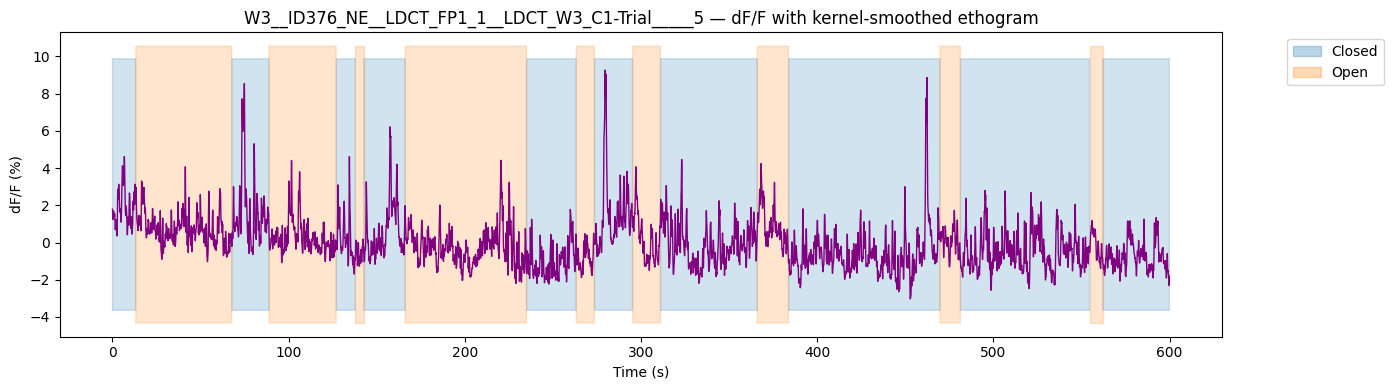

In [34]:
example_key = list(combined_trials.keys())[0]
plot_dff_with_ethogram(combined_trials[example_key], example_key)


In [35]:
print(key, len(fp_traces[key]["timeline_kernel"]))

W3__ID402_WT__LDCT_FP5_2__LDCT_W3_C2_retrack-Trial_____9 18


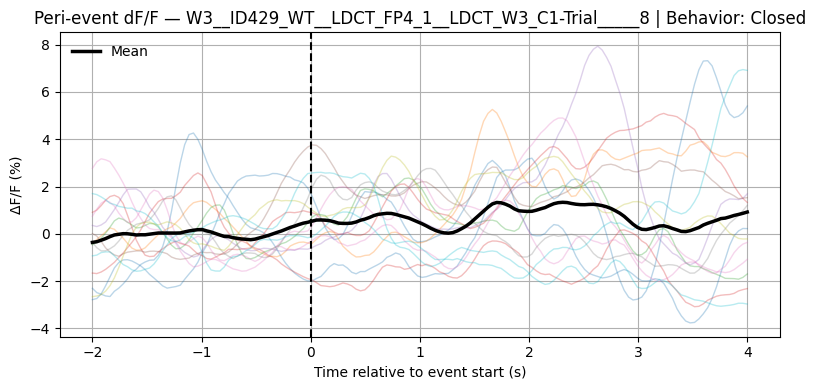

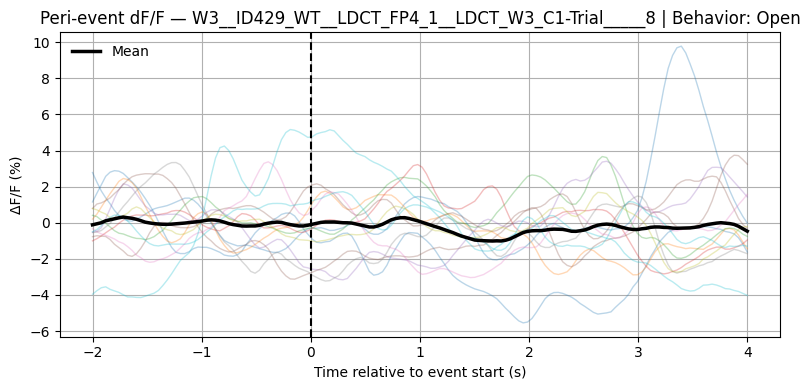

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0      # seconds before event
post_s = 4.0     # seconds after event
min_stay_s = 0   # optional, if you want to filter very short events

# Pick first trial
example_key = list(combined_trials.keys())[3]
df = combined_trials[example_key].copy()

time_vec = df["Time_video"].values
signal_vec = df["dFF"].values
behaviors = df["Behavior"].values

# Unique behaviors
unique_beh = np.unique(behaviors)

# Loop over behaviors
for beh in unique_beh:
    # Find event starts (transition into this behavior)
    mask = (behaviors == beh)
    mask_int = mask.astype(int)  # convert bool to int
    diffs = np.diff(np.r_[0, mask_int])  # prepend 0 for first element
    event_starts_idx = np.where(diffs == 1)[0]  # rising edges

    # Skip if no events
    if len(event_starts_idx) == 0:
        print(f"No events found for {beh}")
        continue

    # Convert pre/post window to samples
    fps = 1 / np.mean(np.diff(time_vec))  # effective sampling rate
    pre_n = int(pre_s * fps)
    post_n = int(post_s * fps)

    # Collect peri-event segments
    segments = []
    for idx in event_starts_idx:
        if idx >= pre_n and (idx + post_n) < len(signal_vec):
            seg = signal_vec[idx-pre_n : idx+post_n].copy()
            seg = seg - np.mean(seg[:pre_n])  # baseline correction
            segments.append(seg)

    if len(segments) == 0:
        print(f"No valid peri-event segments for {beh}")
        continue

    ERF = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,4))
    # Individual traces
    colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:,i], color=col, alpha=0.3, lw=1)
    # Mean trace
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Behavior: {beh}")
    ax.set_xlabel("Time relative to event start (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [37]:
import numpy as np
import pandas as pd

# Pick the trial
example_key = list(combined_trials.keys())[2]
df = combined_trials[example_key]

behaviors = df["Behavior"].values
unique_beh = np.unique(behaviors)

# Count number of instances (rising edges into each behavior)
event_counts = {}

for beh in unique_beh:
    mask = (behaviors == beh)
    mask_int = mask.astype(int)
    diffs = np.diff(np.r_[0, mask_int])  # prepend 0 for first element
    event_starts_idx = np.where(diffs == 1)[0]  # transitions into behavior
    event_counts[beh] = len(event_starts_idx)

# Convert to DataFrame for display
event_counts_df = pd.DataFrame.from_dict(event_counts, orient="index", columns=["Num_Instances"])
event_counts_df.index.name = "Behavior"
event_counts_df


,Num_Instances
Behavior,
Closed,6
Open,5


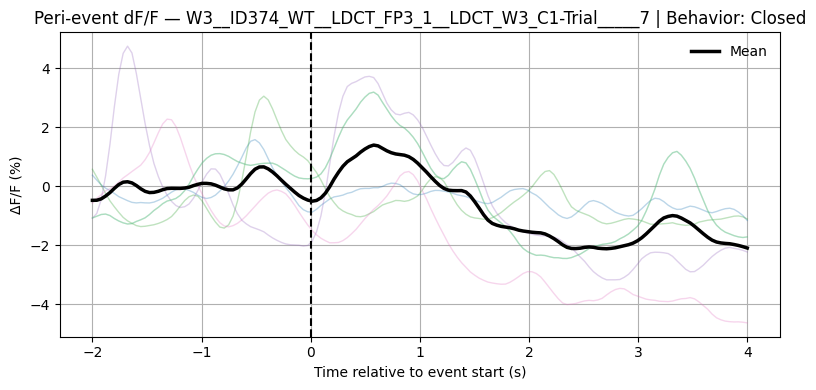

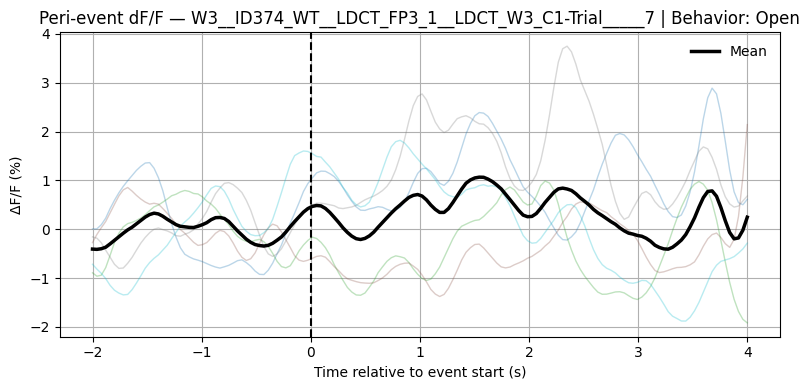

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0   # seconds before event
post_s = 4.0  # seconds after event

# Pick first trial
example_key = list(combined_trials.keys())[2]
df = combined_trials[example_key].copy()
timeline_kernel = fp_traces[example_key]["timeline_kernel"]

signal_vec = df["dFF"].values
time_vec = df["Time_video"].values

# Loop over behaviors using the ethogram segments
for beh in timeline_kernel["Behavior"].unique():
    segments = []

    # Find all start-end intervals for this behavior
    intervals = timeline_kernel[timeline_kernel["Behavior"] == beh]

    for _, row in intervals.iterrows():
        # Find closest index in the FP time vector
        start_idx = np.searchsorted(time_vec, row["Start_time_s"])
        end_idx   = np.searchsorted(time_vec, row["End_time_s"])

        # Peri-event window: pre_s before start, post_s after start
        fps = 1 / np.mean(np.diff(time_vec))
        pre_n = int(pre_s * fps)
        post_n = int(post_s * fps)
        if start_idx >= pre_n and (start_idx + post_n) < len(signal_vec):
            seg = signal_vec[start_idx-pre_n : start_idx+post_n].copy()
            seg = seg - np.mean(seg[:pre_n])  # baseline correction
            segments.append(seg)

    if len(segments) == 0:
        print(f"No valid peri-event segments for {beh}")
        continue

    ERF = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,4))
    # Individual traces
    colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:,i], color=col, alpha=0.3, lw=1)
    # Mean trace
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Behavior: {beh}")
    ax.set_xlabel("Time relative to event start (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [39]:
example_key = list(combined_trials.keys())[0]
df = combined_trials[example_key].copy()

if "timeline_kernel" in fp_traces[example_key]:
    timeline_kernel = fp_traces[example_key]["timeline_kernel"]
else:
    raise ValueError(f"timeline_kernel not found for trial {example_key}")


In [40]:
# bar plots

def map_kernel_to_time_vector(time_vector, timeline_kernel):
    """
    Assign behavior to each FP timepoint exactly as in the ethogram plots.
    Fills gaps with 'Other'.
    """
    behavior_at_time = np.array(["Other"] * len(time_vector), dtype=object)
    
    for _, row in timeline_kernel.iterrows():
        mask = (time_vector >= row["Start_time_s"]) & (time_vector < row["End_time_s"])
        behavior_at_time[mask] = row["Behavior"]
    
    return behavior_at_time


combined_trials = {}

for key in preproc_trials.keys():
    df = preproc_trials[key].copy()
    if "timeline_kernel" in fp_traces[key]:
        timeline_kernel = fp_traces[key]["timeline_kernel"]
        df["Behavior"] = map_kernel_to_time_vector(df["Time_video"].values, timeline_kernel)
    else:
        df["Behavior"] = "Other"  # fallback
    combined_trials[key] = df

import numpy as np
import pandas as pd

# -------------------------------------------------------------
# BUILD mean_summary_df from combined_trials + fp_traces
# -------------------------------------------------------------

mean_rows = []

for trial_key, df in combined_trials.items():

    fp_info = fp_traces[trial_key]

    mouse_id  = fp_info.get("mouse_id")
    genotype  = fp_info.get("genotype")
    condition = fp_info.get("condition")
    week      = fp_info.get("week")

    # behavior labels + signal
    beh = df["Behavior"].values
    dff = df["dFF"].values

    # list of behaviors in the trial
    unique_behaviors = np.unique(beh)

    for b in unique_behaviors:

        mask = beh == b
        if mask.sum() == 0:
            continue

        mean_dff = np.nanmean(dff[mask])
        npoints  = mask.sum()

        mean_rows.append({
            "mouse_id":  mouse_id,
            "genotype":  genotype,
            "condition": condition,
            "week":      week,
            "behavior":  b,
            "mean_dFF":  mean_dff,
            "n_points":  npoints,
            "trial_key": trial_key
        })

mean_summary_df = pd.DataFrame(mean_rows)

print("Created mean_summary_df with shape:", mean_summary_df.shape)
mean_summary_df.head()


Created mean_summary_df with shape: (22, 8)


,mouse_id,genotype,condition,week,behavior,mean_dFF,n_points,trial_key
0,376,NE,None,None,Closed,-0.105980,9261,W3__ID376_NE__LDCT_FP1_1__LDCT_W3_C1-Trial_____5
1,376,NE,None,None,Open,0.171110,5736,W3__ID376_NE__LDCT_FP1_1__LDCT_W3_C1-Trial_____5
2,372,NE,None,None,Closed,-0.558054,11615,W3__ID372_NE__LDCT_FP2_1__LDCT_W3_C1-Trial_____6
3,372,NE,None,None,Open,1.917470,3382,W3__ID372_NE__LDCT_FP2_1__LDCT_W3_C1-Trial_____6
4,374,WT,None,None,Closed,-0.157539,13528,W3__ID374_WT__LDCT_FP3_1__LDCT_W3_C1-Trial_____7


In [41]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---------- PARAMETERS ----------
# pre_s = 2.0
# post_s = 4.0

# # ---------- COLLECT METADATA ----------
# all_behaviors = set()
# all_weeks = set()
# all_genotypes = set()

# for trial_key, trial_data in combined_trials.items():
#     fp_info = fp_traces[trial_key]

#     if fp_info.get("condition") != "Novel":
#         continue

#     behs = np.unique(trial_data["Behavior"].values)
#     all_behaviors.update([b for b in behs if b != "Other"])

#     all_weeks.add(fp_info.get("week"))
#     all_genotypes.add(fp_info.get("genotype"))

# all_behaviors = sorted(all_behaviors)
# all_weeks = sorted(all_weeks)
# all_genotypes = sorted(all_genotypes)


# # =====================================================
# #      MAIN LOOP: BEHAVIOR × GENOTYPE × WEEK
# # =====================================================
# for beh in all_behaviors:

#     fig, axes = plt.subplots(
#         len(all_weeks),
#         len(all_genotypes),
#         figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
#         sharey=True,
#         sharex=True
#     )

#     # ensure 2D axis array
#     if len(all_weeks) == 1:
#         axes = [axes]
#     if len(all_genotypes) == 1:
#         axes = [[axes[r]] for r in range(len(axes))]

#     for r, week in enumerate(all_weeks):
#         for c, genotype in enumerate(all_genotypes):
            
#             ax = axes[r][c]

#             mouse_segments = []
#             mouse_ids = []
#             mouse_lengths = []

#             # ----------------------------------------
#             #          Gather data for cell
#             # ----------------------------------------
#             for trial_key, trial_data in combined_trials.items():
#                 fp_info = fp_traces[trial_key]

#                 if fp_info.get("condition") != "Social":
#                     continue
#                 if fp_info.get("week") != week:
#                     continue
#                 if fp_info.get("genotype") != genotype:
#                     continue

#                 df = trial_data.copy()
#                 time_vec = df["Time_video"].values
#                 signal_vec = df["dFF"].values
#                 behaviors = df["Behavior"].values

#                 if beh not in behaviors:
#                     continue

#                 # ---------- EVENT STARTS ----------
#                 starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]
#                 if len(starts) == 0:
#                     continue

#                 fps = 1.0 / np.mean(np.diff(time_vec))
#                 pre_n = int(pre_s * fps)
#                 post_n = int(post_s * fps)

#                 event_segments = []

#                 for idx in starts:
#                     start_idx = idx - pre_n
#                     stop_idx = idx + post_n

#                     seg_raw = signal_vec[max(0, start_idx):min(stop_idx, len(signal_vec))].copy()

#                     # baseline
#                     if len(seg_raw) > 0:
#                         pre_end = min(pre_n, len(seg_raw))
#                         seg_raw -= np.mean(seg_raw[:pre_end])

#                     event_segments.append(seg_raw)

#                 if len(event_segments) == 0:
#                     continue

#                 # pad event segments to same length within this mouse
#                 max_len_mouse = max(len(s) for s in event_segments)
#                 padded_events = []
#                 for s in event_segments:
#                     padded = np.full(max_len_mouse, np.nan)
#                     padded[:len(s)] = s
#                     padded_events.append(padded)

#                 mouse_mean = np.nanmean(np.vstack(padded_events), axis=0)
#                 mouse_segments.append(mouse_mean)
#                 mouse_ids.append(fp_info.get("mouse_id", trial_key))
#                 mouse_lengths.append(len(mouse_mean))

#             # =================================================
#             #     NOTHING FOR THIS WEEK × GENOTYPE CELL
#             # =================================================
#             if len(mouse_segments) == 0:
#                 ax.set_title(f"{week} | {genotype}\n(no events)")
#                 ax.grid(True)
#                 continue

#             # =================================================
#             #     DETERMINE GLOBAL TARGET LENGTH FOR CELL
#             # =================================================
#             target_len = max(mouse_lengths)

#             # pad all mice to this target_len
#             padded_mouse_segments = []
#             for seg in mouse_segments:
#                 padded = np.full(target_len, np.nan)
#                 padded[:len(seg)] = seg
#                 padded_mouse_segments.append(padded)

#             padded_mouse_segments = np.vstack(padded_mouse_segments)

#             # make time vector for this cell
#             t_window = np.linspace(-pre_s, post_s, target_len)

#             # =================================================
#             #                 PLOTTING
#             # =================================================
#             for i, seg in enumerate(padded_mouse_segments):
#                 ax.plot(t_window, seg, color=plt.cm.tab20(i % 20),
#                         alpha=0.4, lw=1.5)

#             # mean trace
#             grand_mean = np.nanmean(padded_mouse_segments, axis=0)
#             ax.plot(t_window, grand_mean, color="black", lw=2.5)

#             ax.axvline(0, color='k', linestyle='--')
#             ax.set_title(f"{week} | {genotype}")
#             ax.grid(True)

#             if r == len(all_weeks) - 1:
#                 ax.set_xlabel("Time (s)")
#             if c == 0:
#                 ax.set_ylabel("ΔF/F (%)")

#     plt.suptitle(f"Peri-event dF/F — Behavior: {beh} (Social)", fontsize=18)
#     plt.tight_layout()
#     plt.show()


In [42]:
import re

for trial_key, fp_info in fp_traces.items():
    # only fill week if it is missing
    if fp_info.get("week") is None:
        # look for "W<number>" at the start of the trial key
        m = re.match(r"W(\d+)", trial_key)
        if m:
            fp_info["week"] = int(m.group(1))
        else:
            fp_info

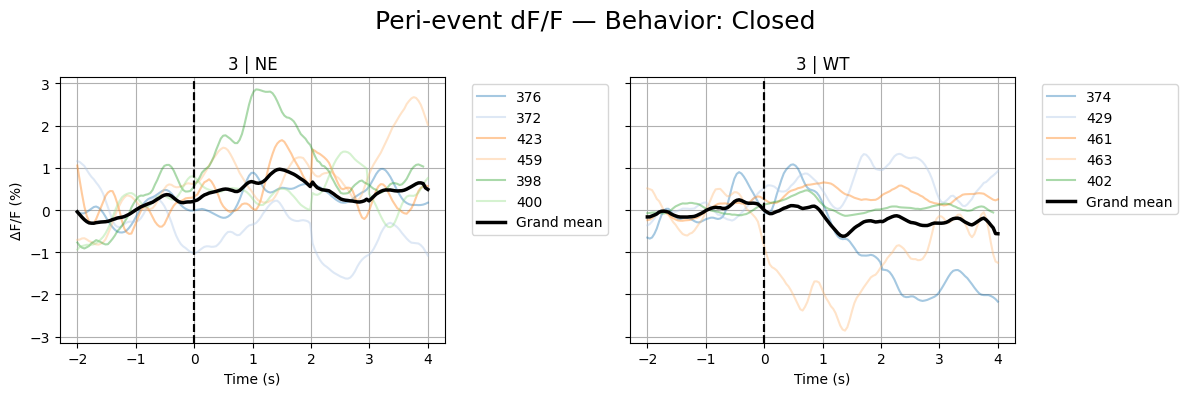

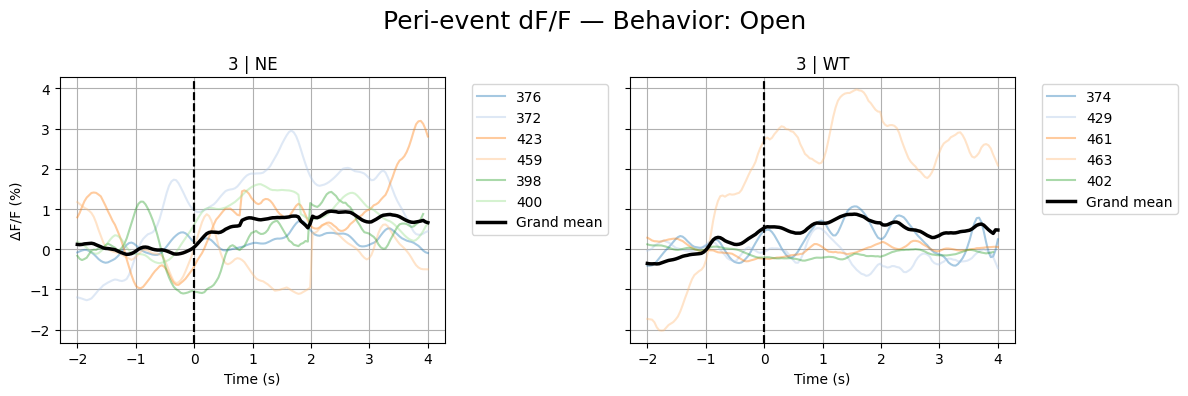

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0
post_s = 4.0

# ---------- COLLECT METADATA ----------
all_behaviors = set()
all_weeks = set()
all_genotypes = set()

for trial_key, trial_data in combined_trials.items():
    fp_info = fp_traces[trial_key]

    # ---------- no condition filter ----------
    behs = np.unique(trial_data["Behavior"].values)
    all_behaviors.update([b for b in behs if b != "Other"])

    all_weeks.add(fp_info.get("week"))
    all_genotypes.add(fp_info.get("genotype"))

all_behaviors = sorted(all_behaviors)
all_weeks = sorted(all_weeks)
all_genotypes = sorted(all_genotypes)

# =====================================================
#      MAIN LOOP: BEHAVIOR × GENOTYPE × WEEK
# =====================================================
for beh in all_behaviors:

    fig, axes = plt.subplots(
        len(all_weeks),
        len(all_genotypes),
        figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
        sharey=True,
        sharex=True
    )

    # ensure 2D axis array
    if len(all_weeks) == 1:
        axes = [axes]
    if len(all_genotypes) == 1:
        axes = [[axes[r]] for r in range(len(axes))]

    for r, week in enumerate(all_weeks):
        for c, genotype in enumerate(all_genotypes):
            
            ax = axes[r][c]

            mouse_segments = []
            mouse_ids = []
            mouse_lengths = []

            # ----------------------------------------
            #          Gather data for cell
            # ----------------------------------------
            for trial_key, trial_data in combined_trials.items():
                fp_info = fp_traces[trial_key]

                # ---------- no condition filter ----------
                if fp_info.get("week") != week:
                    continue
                if fp_info.get("genotype") != genotype:
                    continue

                df = trial_data.copy()
                time_vec = df["Time_video"].values
                signal_vec = df["dFF"].values
                behaviors = df["Behavior"].values

                if beh not in behaviors:
                    continue

                # ---------- EVENT STARTS ----------
                starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]
                if len(starts) == 0:
                    continue

                fps = 1.0 / np.mean(np.diff(time_vec))
                pre_n = int(pre_s * fps)
                post_n = int(post_s * fps)

                event_segments = []

                for idx in starts:
                    start_idx = idx - pre_n
                    stop_idx = idx + post_n

                    seg_raw = signal_vec[max(0, start_idx):min(stop_idx, len(signal_vec))].copy()

                    # baseline
                    if len(seg_raw) > 0:
                        pre_end = min(pre_n, len(seg_raw))
                        seg_raw -= np.mean(seg_raw[:pre_end])

                    event_segments.append(seg_raw)

                if len(event_segments) == 0:
                    continue

                # pad event segments to same length within this mouse
                max_len_mouse = max(len(s) for s in event_segments)
                padded_events = []
                for s in event_segments:
                    padded = np.full(max_len_mouse, np.nan)
                    padded[:len(s)] = s
                    padded_events.append(padded)

                mouse_mean = np.nanmean(np.vstack(padded_events), axis=0)
                mouse_segments.append(mouse_mean)
                mouse_ids.append(fp_info.get("mouse_id", trial_key))
                mouse_lengths.append(len(mouse_mean))

            # =================================================
            #     NOTHING FOR THIS WEEK × GENOTYPE CELL
            # =================================================
            if len(mouse_segments) == 0:
                ax.set_title(f"{week} | {genotype}\n(no events)")
                ax.grid(True)
                continue

            # =================================================
            #     DETERMINE GLOBAL TARGET LENGTH FOR CELL
            # =================================================
            target_len = max(mouse_lengths)

            # pad all mice to this target_len
            padded_mouse_segments = []
            for seg in mouse_segments:
                padded = np.full(target_len, np.nan)
                padded[:len(seg)] = seg
                padded_mouse_segments.append(padded)

            padded_mouse_segments = np.vstack(padded_mouse_segments)

            # make time vector for this cell
            t_window = np.linspace(-pre_s, post_s, target_len)


            # =================================================
            #                 PLOTTING
            # =================================================
            lines = []
            for i, seg in enumerate(padded_mouse_segments):
                color = plt.cm.tab20(i % 20)
                line, = ax.plot(t_window, seg, color=color, alpha=0.4, lw=1.5)
                lines.append((line, mouse_ids[i]))  # store line and mouse_id for legend

            # mean trace
            grand_mean = np.nanmean(padded_mouse_segments, axis=0)
            ax.plot(t_window, grand_mean, color="black", lw=2.5, label="Grand mean")

            ax.axvline(0, color='k', linestyle='--')

            # Add legend for mice
            mouse_lines = [line for line, _ in lines]
            mouse_labels = [str(mid) for _, mid in lines]
            ax.legend(mouse_lines + [plt.Line2D([0], [0], color='black', lw=2.5)],
                    mouse_labels + ["Grand mean"],
                    bbox_to_anchor=(1.05, 1), loc="upper left")

            ax.axvline(0, color='k', linestyle='--')
            ax.set_title(f"{week} | {genotype}")
            ax.grid(True)

            if r == len(all_weeks) - 1:
                ax.set_xlabel("Time (s)")
            if c == 0:
                ax.set_ylabel("ΔF/F (%)")

    plt.suptitle(f"Peri-event dF/F — Behavior: {beh}", fontsize=18)
    plt.tight_layout()
    plt.show()   

In [44]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# def plot_behavior_facet_genotype_with_lines(mean_df, condition_filter=None):
#     """
#     For each behavior (excluding 'Other'):
#         • One figure with NE/WT facets
#         • x-axis = week
#         • bars = mean ± SEM
#         • points = each mouse
#         • lines = connect same mouse across weeks
#     """

#     df = mean_df.copy()

#     # # Filter specific condition (Social, Novel, Hab)
#     # if condition_filter is not None:
#     #     df = df[df["condition"] == condition_filter]

#     # Remove "Other"
#     df = df[df["behavior"] != "Other"]

#     if df.empty:
#         print(f"[WARN] No data available after filtering for '{condition_filter}' and excluding 'Other'")
#         return

#     # Ordered weeks
#     week_order = ["Preinduction", "W1", "W2", "W3"]
#     df["week"] = pd.Categorical(df["week"], categories=week_order, ordered=True)

#     # Ordered genotype facets
#     genotype_order = ["NE", "WT"]
#     df["genotype"] = pd.Categorical(df["genotype"], categories=genotype_order, ordered=True)

#     # Behaviors to plot
#     behaviors = sorted(df["behavior"].unique())

#     for beh in behaviors:
#         sub = df[df["behavior"] == beh]
#         if sub.empty:
#             continue

#         # --- FACET SETUP ---
#         g = sns.FacetGrid(
#             sub,
#             col="genotype",
#             col_order=genotype_order,
#             height=5,
#             aspect=1.1,
#             sharey=True
#         )

#         # --- BARPLOT (mean ± SEM) ---
#         g.map_dataframe(
#             sns.barplot,
#             x="week",
#             y="mean_dFF",
#             order=week_order,
#             palette="Set2",
#             errorbar="se",
#             alpha=0.8,
#             width=0.65
#         )

#         # --- POINTS (each mouse) ---
#         g.map_dataframe(
#             sns.stripplot,
#             x="week",
#             y="mean_dFF",
#             order=week_order,
#             color="black",
#             size=6,
#             alpha=0.8,
#             jitter=False
#         )

#         # --- LINES TRACKING EACH MOUSE ACROSS WEEKS ---
#         def add_mouse_lines(data, color=None, **kwargs):
#             """
#             Draw lines connecting the same mouse across weeks inside each facet.
#             """
#             mice = data["mouse_id"].unique()
#             for m in mice:
#                 df_m = data[data["mouse_id"] == m].sort_values("week")
#                 plt.plot(df_m["week"], df_m["mean_dFF"],
#                          marker="o",
#                          color="black",
#                          alpha=0.5,
#                          linewidth=1.2)

#         g.map_dataframe(add_mouse_lines)

#         # --- STYLE ---
#         g.set_axis_labels("Week", "Mean ΔF/F (%)")
#         g.set_titles("{col_name}")  # genotype as title (NE, WT)
#         g.fig.suptitle(f"Behavior: {beh} — ΔF/F across weeks (mouse trajectories)", fontsize=16, y=1.05)

#         for ax in g.axes.flatten():
#             ax.grid(axis="y", alpha=0.3)

#         plt.tight_layout()
#         plt.show()


In [45]:
import re

def extract_week_from_trial_key(trial_key):
    m = re.match(r"(W\d+)", trial_key)
    return m.group(1) if m else None

# Fill 'week' column in your dataframe
mean_summary_df["week"] = mean_summary_df["trial_key"].apply(extract_week_from_trial_key)

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_behavior_facet_genotype_with_lines(mean_df, condition_filter=None):
    """
    For each behavior (excluding 'Other'):
        • One figure with NE/WT facets
        • x-axis = week
        • bars = mean ± SEM
        • points = each mouse
        • lines = connect same mouse across weeks
    """

    df = mean_df.copy()

    # Remove "Other"
    df = df[df["behavior"] != "Other"]

    if df.empty:
        print(f"[WARN] No data available after filtering and excluding 'Other'")
        return

    # --- Ordered weeks and genotype ---
    week_order = ["Preinduction", "W1", "W2", "W3"]
    df["week"] = pd.Categorical(df["week"], categories=week_order, ordered=True)

    genotype_order = ["NE", "WT"]
    df["genotype"] = pd.Categorical(df["genotype"], categories=genotype_order, ordered=True)

    # --- Behaviors to plot ---
    behaviors = sorted(df["behavior"].unique())

    for beh in behaviors:
        sub = df[df["behavior"] == beh]
        if sub.empty:
            continue

        # --- FACET GRID ---
        g = sns.FacetGrid(
            sub,
            col="genotype",
            col_order=genotype_order,
            height=5,
            aspect=1.1,
            sharey=True
        )

        # --- BARPLOT (mean ± SEM) ---
        g.map_dataframe(
            sns.barplot,
            x="week",
            y="mean_dFF",
            order=week_order,
            palette="Set2",
            ci=68,  # approximate SEM
            alpha=0.8,
            width=0.65
        )

        # --- POINTS (each mouse) ---
        g.map_dataframe(
            sns.stripplot,
            x="week",
            y="mean_dFF",
            order=week_order,
            color="black",
            size=6,
            alpha=0.8,
            jitter=False
        )

        # --- LINES CONNECTING SAME MOUSE ACROSS WEEKS ---
        def add_mouse_lines(data, **kwargs):
            mice = data["mouse_id"].unique()
            for m in mice:
                df_m = data[data["mouse_id"] == m].sort_values("week")
                # convert week to numeric positions
                week_pos = [week_order.index(w) for w in df_m["week"]]
                plt.plot(
                    week_pos,
                    df_m["mean_dFF"],
                    marker="o",
                    color="black",
                    alpha=0.5,
                    linewidth=1.2
                )

        g.map_dataframe(add_mouse_lines)

        # --- STYLE & AXES ---
        g.set_axis_labels("Week", "Mean ΔF/F (%)")
        g.set_titles("{col_name}")  # genotype as facet title

        # Fix x-axis ticks to show week names
        for ax in g.axes.flatten():
            ax.set_xticks(range(len(week_order)))
            ax.set_xticklabels(week_order)
            ax.grid(axis="y", alpha=0.3)

        g.fig.suptitle(f"Behavior: {beh} — ΔF/F across weeks (mouse trajectories)",
                       fontsize=16, y=1.05)

        plt.tight_layout()
        plt.show()

/Users/annastuckert/anaconda3/envs/napari/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/annastuckert/anaconda3/envs/napari/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/annastuckert/anaconda3/envs/napari/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/annastuckert/anaconda3/envs/napari/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `

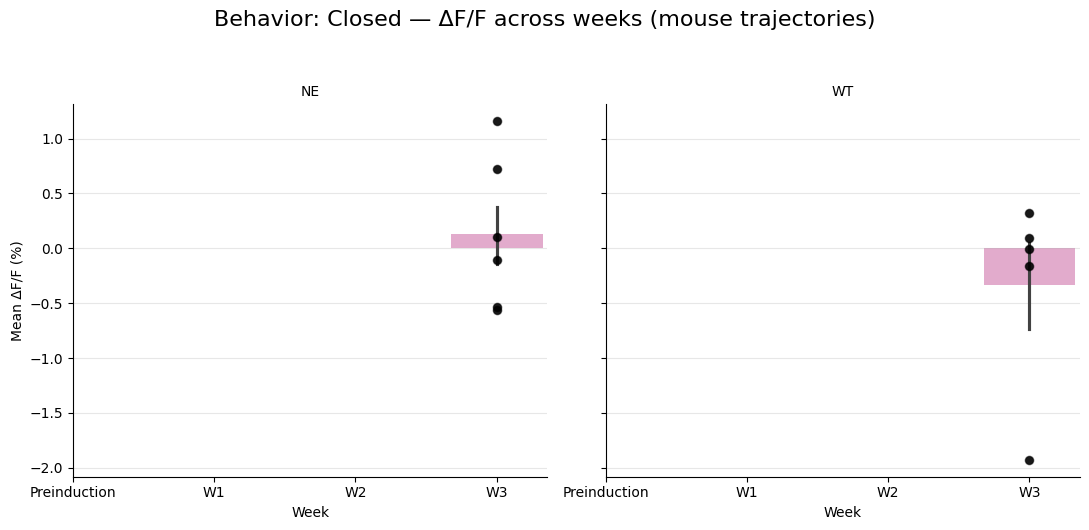

/Users/annastuckert/anaconda3/envs/napari/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/annastuckert/anaconda3/envs/napari/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/annastuckert/anaconda3/envs/napari/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/annastuckert/anaconda3/envs/napari/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `

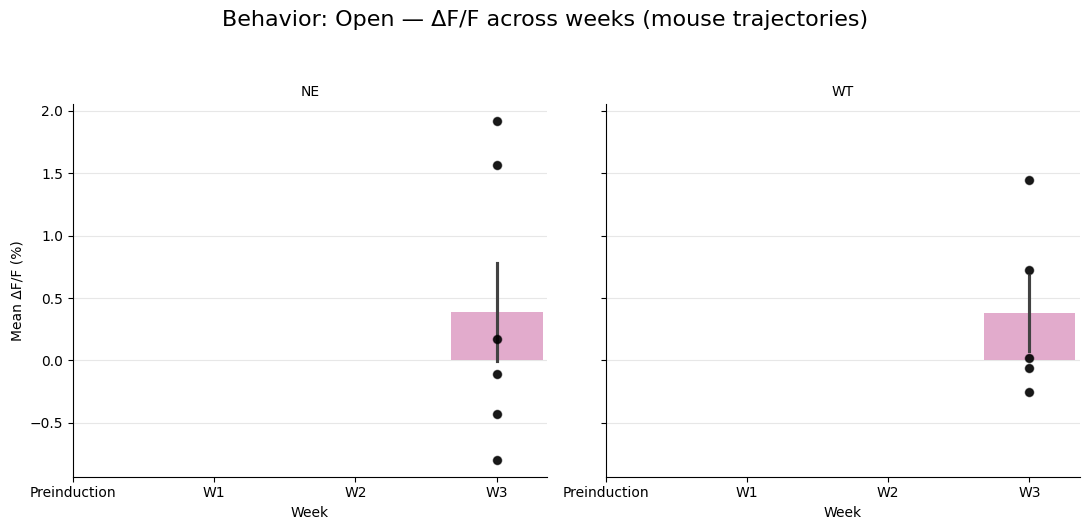

In [47]:
plot_behavior_facet_genotype_with_lines(mean_summary_df)


In [48]:
print(mean_summary_df["genotype"].unique())


['NE' 'WT']
